In [1]:
# imports libs 
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.preprocessing import LabelEncoder
from scipy.stats.mstats import winsorize
from sklearn.ensemble import HistGradientBoostingClassifier
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

In [2]:
# lendo dataset
df = pd.read_csv('C:\\Users\\souza\\OneDrive\\Área de Trabalho\\Risk Nubank\\data\\acquisition_train.csv', delimiter=',')
df

,ids,target_default,score_1,score_2,score_3,score_4,score_5,score_6,risk_rate,last_amount_borrowed,...,external_data_provider_fraud_score,lat_lon,marketing_channel,profile_phone_number,reported_income,shipping_state,shipping_zip_code,profile_tags,user_agent,target_fraud
0,343b7e7b-2cf8-e508-b8fd-0a0285af30aa,False,1Rk8w4Ucd5yR3KcqZzLdow==,IOVu8au3ISbo6+zmfnYwMg==,350.0,101.800832,0.259555,108.427273,0.40,25033.92,...,645,"(-29.151545708122246, -51.1386461804385)",Invite-email,514-9840782,57849.0,BR-MT,17528,"{'tags': ['n19', 'n8']}",Mozilla/5.0 (Linux; Android 6.0.1; SGP771 Buil...,NaN
1,bc2c7502-bbad-0f8c-39c3-94e881967124,False,DGCQep2AE5QRkNCshIAlFQ==,SaamrHMo23l/3TwXOWgVzw==,370.0,97.062615,0.942655,92.002546,0.24,NaN,...,243,"(-19.687710705798963, -47.94151536525154)",Radio-commercial,251-3659293,4902.0,BR-RS,40933,"{'tags': ['n6', 'n7', 'nim']}",Mozilla/5.0 (Linux; Android 5.0.2; SAMSUNG SM-...,NaN
2,669630dd-2e6a-0396-84bf-455e5009c922,True,DGCQep2AE5QRkNCshIAlFQ==,Fv28Bz0YRTVAT5kl1bAV6g==,360.0,100.027073,0.351918,112.892453,0.29,7207.92,...,65,"(-28.748023890412284, -51.867279334353995)",Waiting-list,230-6097993,163679.0,BR-RR,50985,"{'tags': ['n0', 'n17', 'nim', 'da']}",Mozilla/5.0 (Linux; Android 6.0.1; SGP771 Buil...,NaN
3,d235609e-b6cb-0ccc-a329-d4f12e7ebdc1,False,1Rk8w4Ucd5yR3KcqZzLdow==,dCm9hFKfdRm7ej3jW+gyxw==,510.0,101.599485,0.987673,94.902491,0.32,NaN,...,815,"(-17.520650158450454, -39.75801139933186)",Waiting-list,261-3543751,1086.0,BR-RN,37825,{'tags': ['n4']},Mozilla/5.0 (Linux; Android 6.0; HTC One X10 B...,NaN
4,9e0eb880-e8f4-3faa-67d8-f5cdd2b3932b,False,8k8UDR4Yx0qasAjkGrUZLw==,+CxEO4w7jv3QPI/BQbyqAA==,500.0,98.474289,0.532539,118.126207,0.18,NaN,...,320,"(-16.574259446978008, -39.90990074785962)",Invite-email,102-3660162,198618.0,BR-MT,52827,"{'tags': ['pro+aty', 'n19', 'da', 'b19']}",Mozilla/5.0 (Linux; Android 7.0; Pixel C Build...,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44995,696cb747-1159-0a29-6731-8c52c6c42f5d,False,DGCQep2AE5QRkNCshIAlFQ==,SaamrHMo23l/3TwXOWgVzw==,280.0,96.379531,0.416693,103.667082,0.17,14766.42,...,730,"(-22.486891256430695, -44.909010639017616)",Facebook,768-5074915,73417.0,BR-GO,52148,"{'tags': ['n1', 'n7', 'n4', 'n0']}",Mozilla/5.0 (Linux; Android 6.0.1; SM-G920V Bu...,NaN
44996,92cd9b1a-9a8e-43ad-5d96-8e999128b472,False,smzX0nxh5QlePvtVf6EAeg==,vJyc9xom9v7hwFMPTIpmKw==,370.0,96.124977,0.692196,97.977973,0.27,NaN,...,28,"(-12.881449687799003, -46.43545330884514)",Waiting-list,772-3517810,26246.0,BR-RO,46084,"{'tags': ['n11', 'n5', 'n12']}",Mozilla/5.0 (X11; CrOS x86_64 8172.45.0) Apple...,NaN
44997,febdd174-cf18-0be1-feb8-38399dd67d9e,False,e4NYDor1NOw6XKGE60AWFw==,ky19q4V1ZqgL3jnHX0wKDw==,280.0,102.377780,0.530938,93.687747,0.30,NaN,...,940,"(-23.888982131800983, -50.645313285616645)",Waiting-list,334-9885724,101252.0,BR-SP,30570,"{'tags': ['dfa', 'c55', 'pro+aty']}",Mozilla/5.0 (Linux; Android 5.0.2; LG-V410/V41...,NaN
44998,a0a5a872-6165-b939-b711-37d045a0b5a8,True,smzX0nxh5QlePvtVf6EAeg==,6J1ZMTzN5GKHXnhM4J1JbA==,240.0,100.476090,0.214697,86.759074,0.37,NaN,...,459,"(-5.14769885524928, -37.98386842511541)",Instagram,238-9568414,129844.0,BR-SP,12742,"{'tags': ['n9', 'n2']}",Mozilla/5.0 (Linux; Android 5.0.2; SAMSUNG SM-...,NaN


In [3]:
# columns infos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 43 columns):
 #   Column                                            Non-Null Count  Dtype  
---  ------                                            --------------  -----  
 0   ids                                               45000 non-null  object 
 1   target_default                                    41741 non-null  object 
 2   score_1                                           44438 non-null  object 
 3   score_2                                           44438 non-null  object 
 4   score_3                                           44438 non-null  float64
 5   score_4                                           45000 non-null  float64
 6   score_5                                           45000 non-null  float64
 7   score_6                                           45000 non-null  float64
 8   risk_rate                                         44438 non-null  float64
 9   last_amount_borro

In [4]:
df.columns

Index(['ids', 'target_default', 'score_1', 'score_2', 'score_3', 'score_4',
       'score_5', 'score_6', 'risk_rate', 'last_amount_borrowed',
       'last_borrowed_in_months', 'credit_limit', 'reason', 'income',
       'facebook_profile', 'state', 'zip', 'channel', 'job_name', 'real_state',
       'ok_since', 'n_bankruptcies', 'n_defaulted_loans', 'n_accounts',
       'n_issues', 'application_time_applied', 'application_time_in_funnel',
       'email', 'external_data_provider_credit_checks_last_2_year',
       'external_data_provider_credit_checks_last_month',
       'external_data_provider_credit_checks_last_year',
       'external_data_provider_email_seen_before',
       'external_data_provider_first_name',
       'external_data_provider_fraud_score', 'lat_lon', 'marketing_channel',
       'profile_phone_number', 'reported_income', 'shipping_state',
       'shipping_zip_code', 'profile_tags', 'user_agent', 'target_fraud'],
      dtype='object')

In [5]:

df.describe()

,score_3,score_4,score_5,score_6,risk_rate,last_amount_borrowed,last_borrowed_in_months,credit_limit,income,ok_since,...,n_accounts,n_issues,application_time_in_funnel,external_data_provider_credit_checks_last_2_year,external_data_provider_credit_checks_last_month,external_data_provider_credit_checks_last_year,external_data_provider_email_seen_before,external_data_provider_fraud_score,reported_income,shipping_zip_code
count,44438.000000,45000.000000,45000.000000,45000.000000,44438.000000,15044.000000,15044.000000,31200.000000,4.443800e+04,18455.000000,...,44438.000000,33456.000000,45000.000000,22372.0,45000.000000,29876.000000,42767.000000,45000.000000,45000.00,45000.000000
mean,347.983258,100.006797,0.500037,99.925228,0.296717,13782.341991,41.763893,34381.951154,7.160739e+04,35.069737,...,10.696701,11.068119,247.537000,0.0,1.501067,0.503381,12.534781,500.399800,inf,33923.514844
std,110.429165,3.178080,0.288326,10.016549,0.101933,8077.571933,10.252705,36586.982218,5.185897e+04,21.663194,...,4.592463,4.595501,146.118398,0.0,1.114941,0.499997,126.530487,287.968873,NaN,12692.406382
min,0.000000,86.191572,0.000035,60.663039,0.000000,1005.180000,36.000000,0.000000,4.821180e+03,0.000000,...,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,-999.000000,0.000000,403.00,12001.000000
25%,270.000000,97.867036,0.252150,93.198353,0.220000,7519.502500,36.000000,10000.000000,4.501078e+04,17.000000,...,7.000000,8.000000,120.000000,0.0,1.000000,0.000000,11.000000,252.000000,50948.25,22937.000000
50%,340.000000,100.018900,0.500753,99.974796,0.290000,12023.465000,36.000000,25647.000000,6.126676e+04,32.000000,...,10.000000,10.000000,248.000000,0.0,2.000000,1.000000,27.000000,503.000000,101779.00,33896.000000
75%,420.000000,102.141797,0.748816,106.640275,0.360000,19220.270000,36.000000,47086.750000,8.601923e+04,50.000000,...,13.000000,14.000000,375.000000,0.0,2.000000,1.000000,43.000000,747.000000,151337.25,44910.000000
max,990.000000,113.978234,0.999973,142.192400,0.900000,35059.600000,60.000000,448269.000000,5.000028e+06,141.000000,...,49.000000,49.000000,500.000000,0.0,3.000000,1.000000,59.000000,1000.000000,inf,56000.000000


In [6]:
# nan values 
df.isnull().sum()

ids                                                     0
target_default                                       3259
score_1                                               562
score_2                                               562
score_3                                               562
score_4                                                 0
score_5                                                 0
score_6                                                 0
risk_rate                                             562
last_amount_borrowed                                29956
last_borrowed_in_months                             29956
credit_limit                                        13800
reason                                                566
income                                                562
facebook_profile                                     4458
state                                                 562
zip                                                   562
channel       

In [7]:
df.columns

Index(['ids', 'target_default', 'score_1', 'score_2', 'score_3', 'score_4',
       'score_5', 'score_6', 'risk_rate', 'last_amount_borrowed',
       'last_borrowed_in_months', 'credit_limit', 'reason', 'income',
       'facebook_profile', 'state', 'zip', 'channel', 'job_name', 'real_state',
       'ok_since', 'n_bankruptcies', 'n_defaulted_loans', 'n_accounts',
       'n_issues', 'application_time_applied', 'application_time_in_funnel',
       'email', 'external_data_provider_credit_checks_last_2_year',
       'external_data_provider_credit_checks_last_month',
       'external_data_provider_credit_checks_last_year',
       'external_data_provider_email_seen_before',
       'external_data_provider_first_name',
       'external_data_provider_fraud_score', 'lat_lon', 'marketing_channel',
       'profile_phone_number', 'reported_income', 'shipping_state',
       'shipping_zip_code', 'profile_tags', 'user_agent', 'target_fraud'],
      dtype='object')

In [8]:
# selecionando apenas variaveis importantes para o problema 
df2 = df.copy()
df2 = df2[['target_default', 'score_3', 'risk_rate', 'credit_limit', 'income', 'n_defaulted_loans', 'n_accounts', 'n_issues',
            'ok_since', 'n_bankruptcies', 'external_data_provider_credit_checks_last_year', 'external_data_provider_credit_checks_last_month', 
            'external_data_provider_credit_checks_last_2_year', 'reported_income']]

In [9]:
df2.isnull().sum()

target_default                                       3259
score_3                                               562
risk_rate                                             562
credit_limit                                        13800
income                                                562
n_defaulted_loans                                     574
n_accounts                                            562
n_issues                                            11544
ok_since                                            26545
n_bankruptcies                                        697
external_data_provider_credit_checks_last_year      15124
external_data_provider_credit_checks_last_month         0
external_data_provider_credit_checks_last_2_year    22628
reported_income                                         0
dtype: int64

In [10]:
# selecionando variaveis para drop 
nan_variables = ['score_3', 'risk_rate', 'income', 'n_defaulted_loans', 'n_accounts']
df2 = df2.dropna(subset=nan_variables)

In [11]:
df2.isnull().sum()

target_default                                       2697
score_3                                                 0
risk_rate                                               0
credit_limit                                        13226
income                                                  0
n_defaulted_loans                                       0
n_accounts                                              0
n_issues                                            10970
ok_since                                            25983
n_bankruptcies                                        123
external_data_provider_credit_checks_last_year      14906
external_data_provider_credit_checks_last_month         0
external_data_provider_credit_checks_last_2_year    22348
reported_income                                         0
dtype: int64

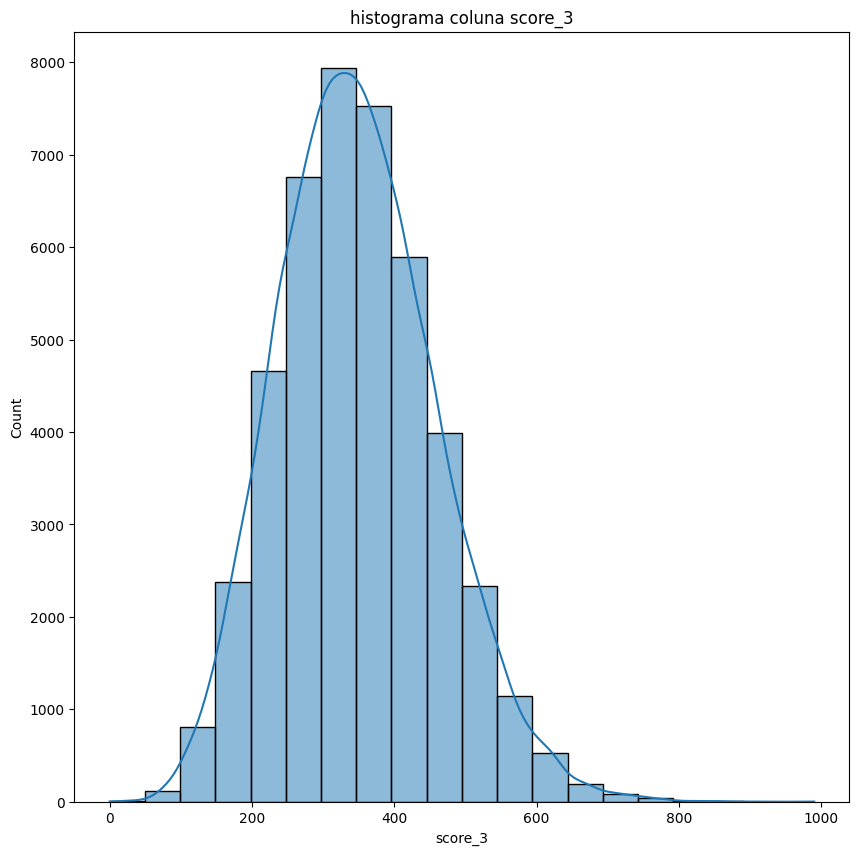

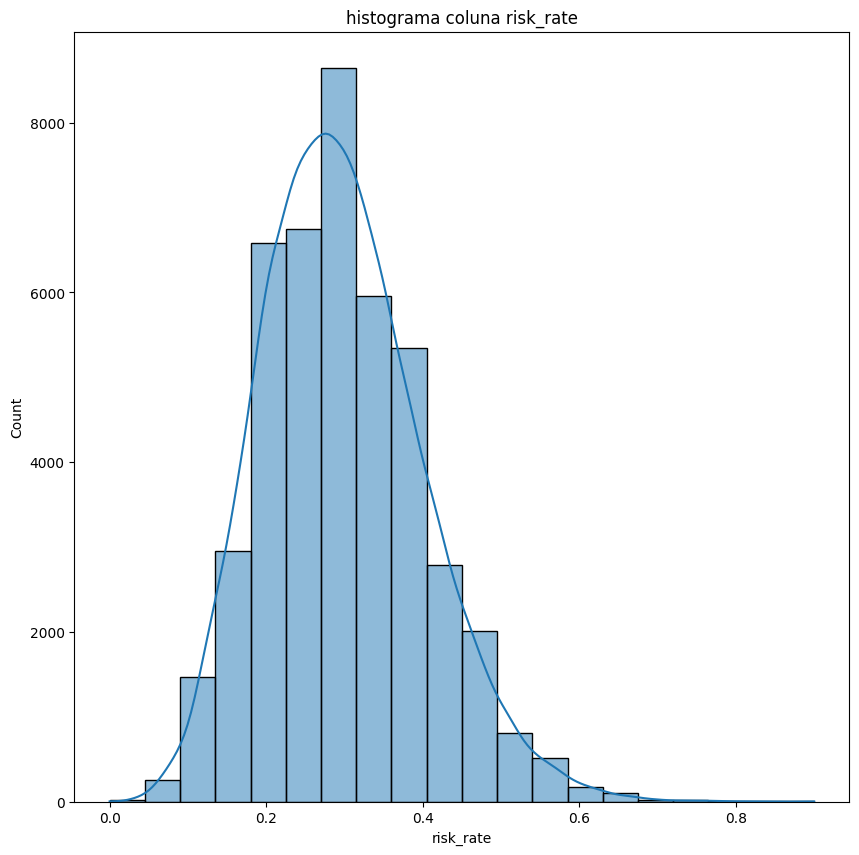

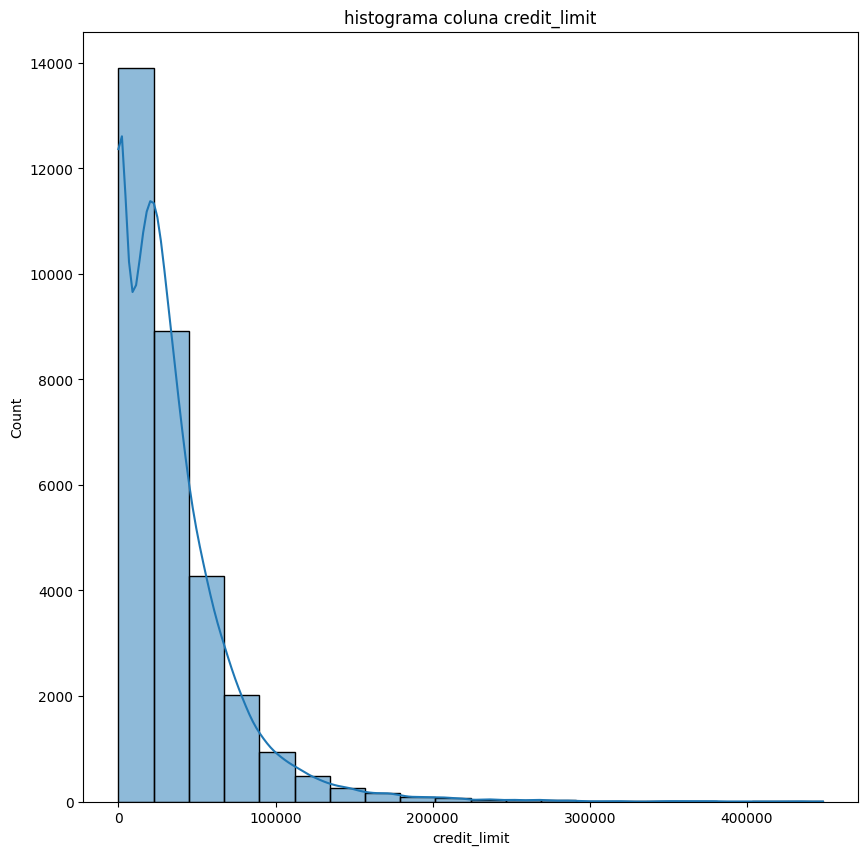

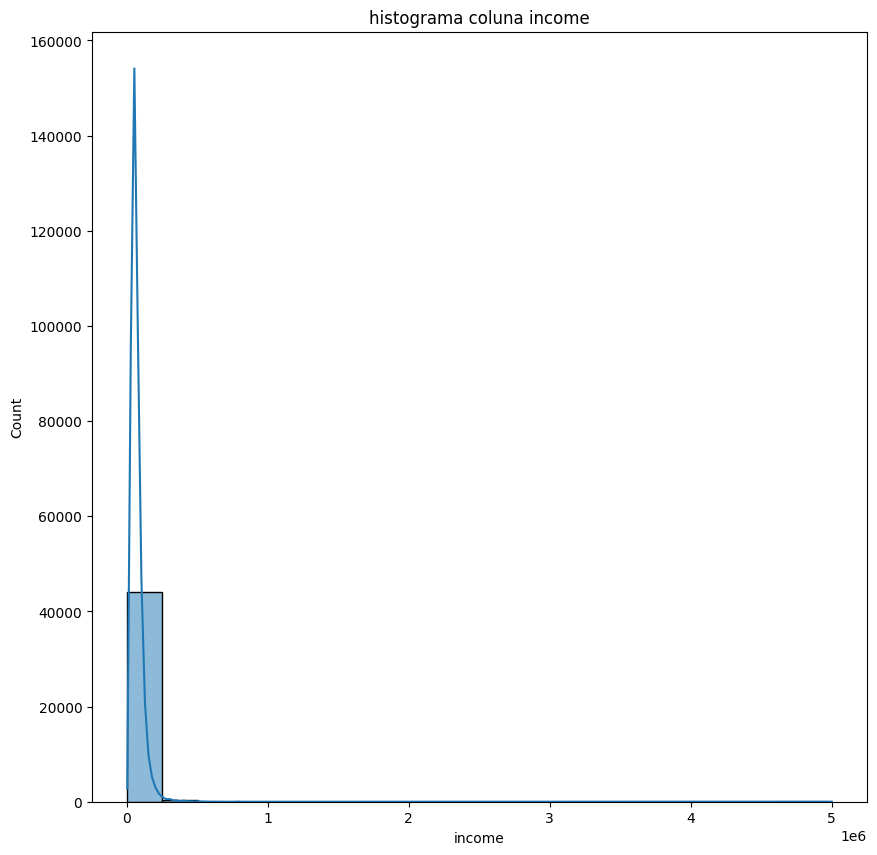

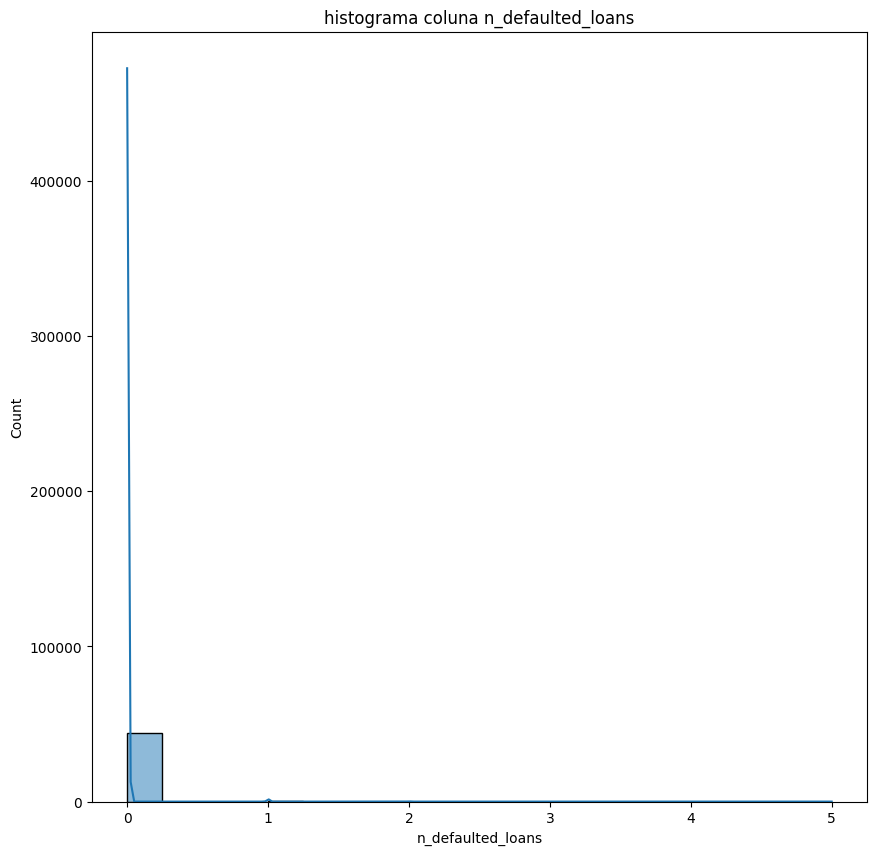

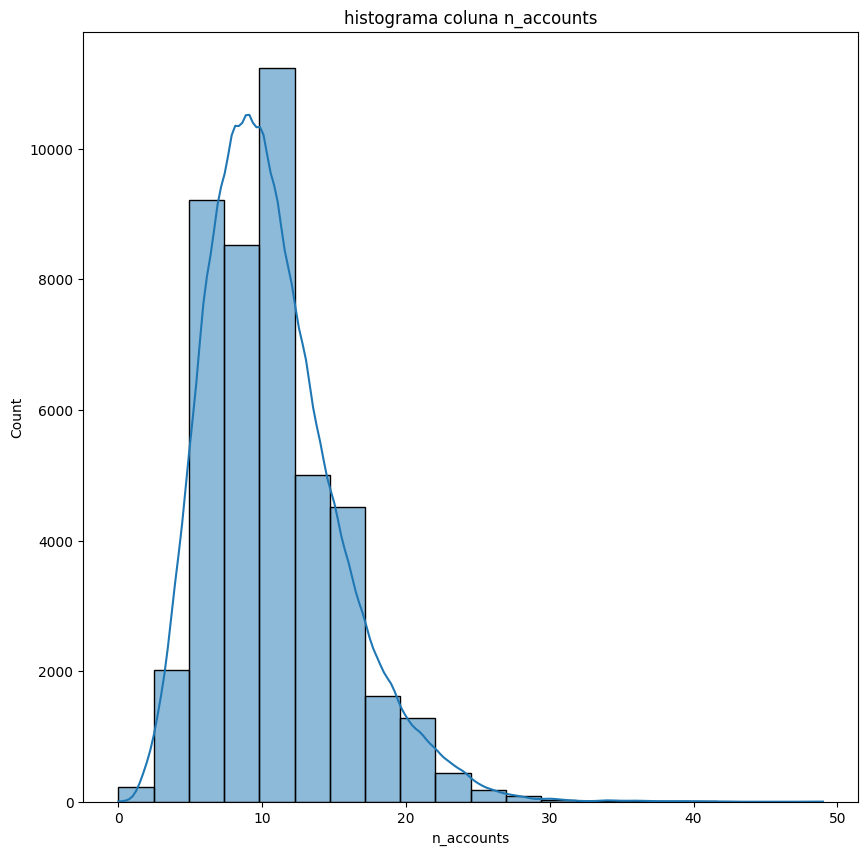

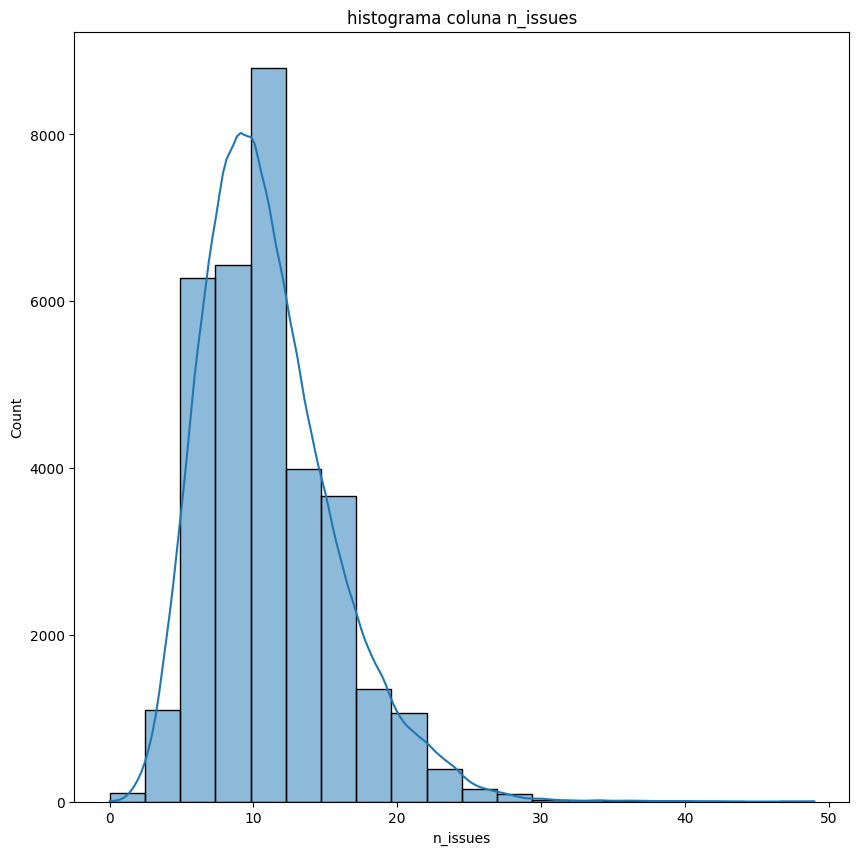

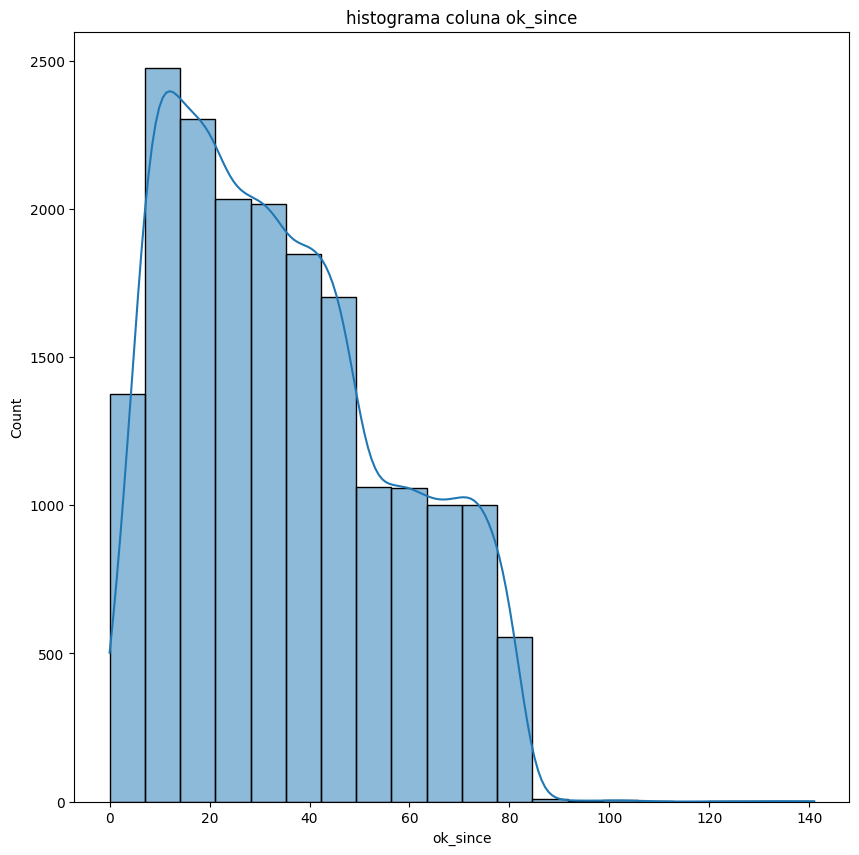

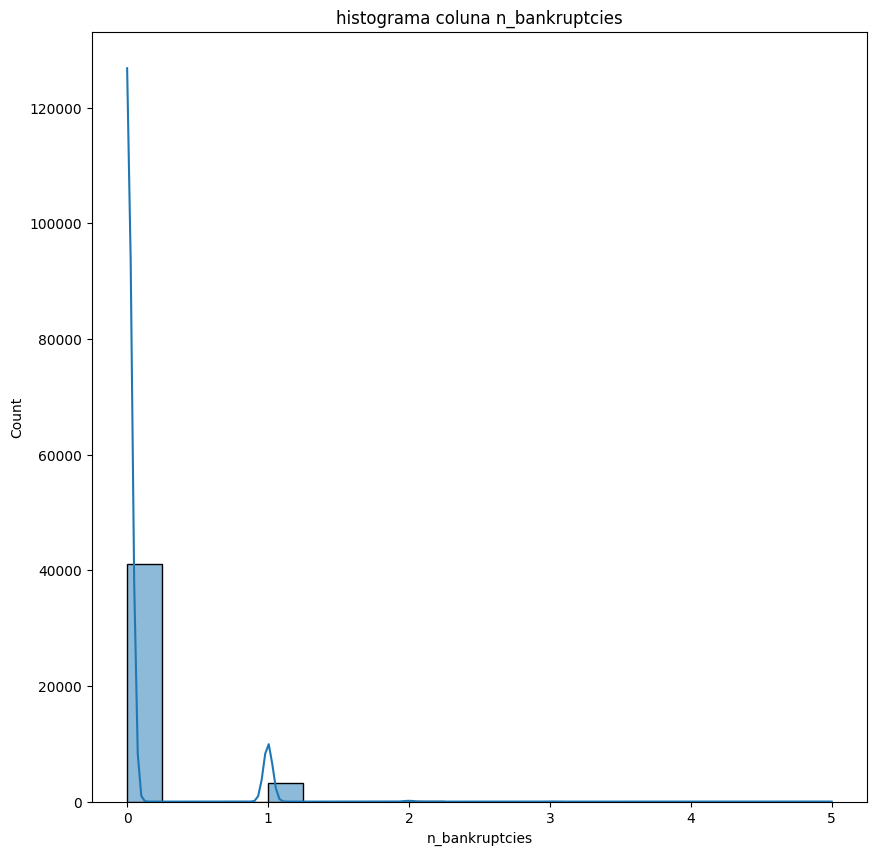

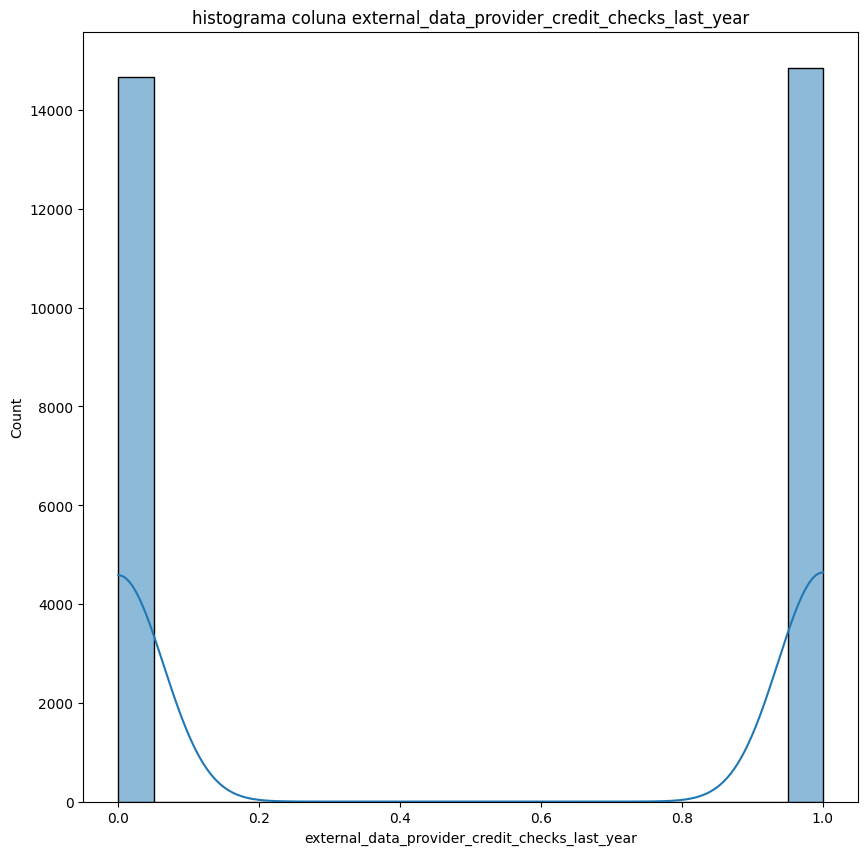

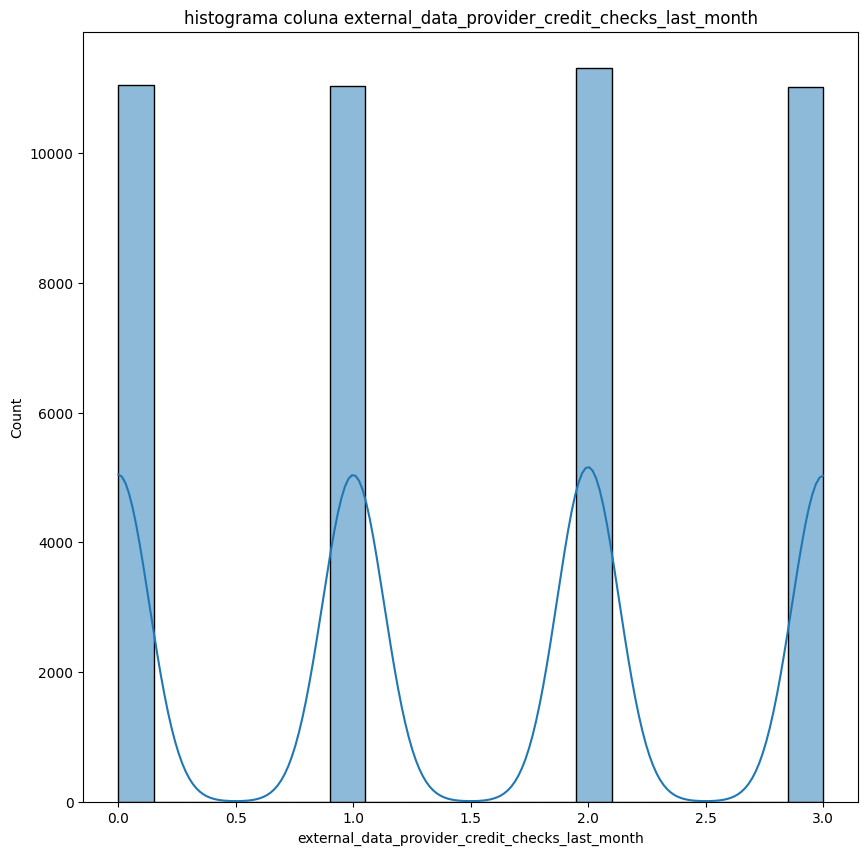

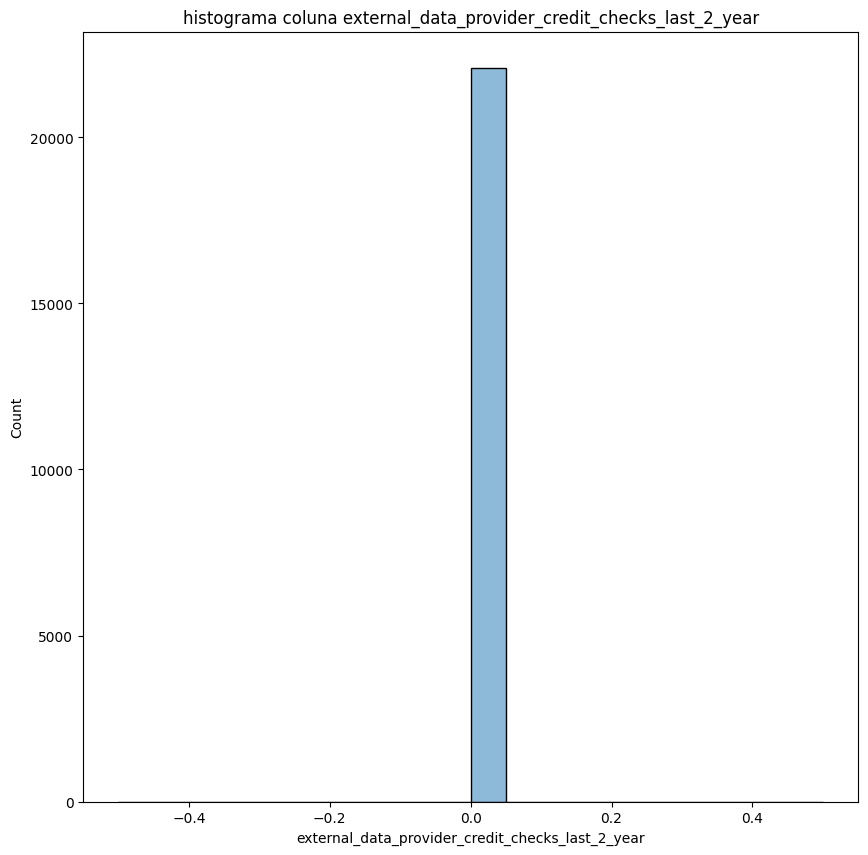

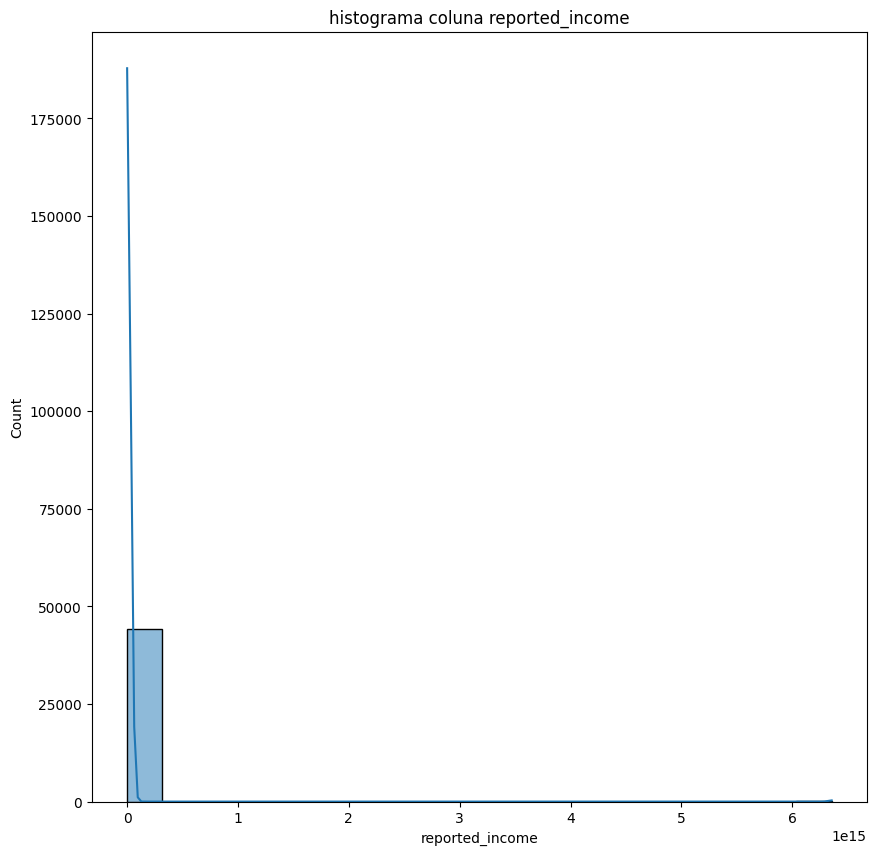

In [12]:
# buscando entender as distribuiçoes das variaveis numericas do nosso problema 
num_col = df2.select_dtypes(exclude='object')
for num in num_col:
    plt.figure(figsize=(10,10))
    plt.title(f'histograma coluna {num}')
    sns.histplot(df2[num], kde=True, bins=20)

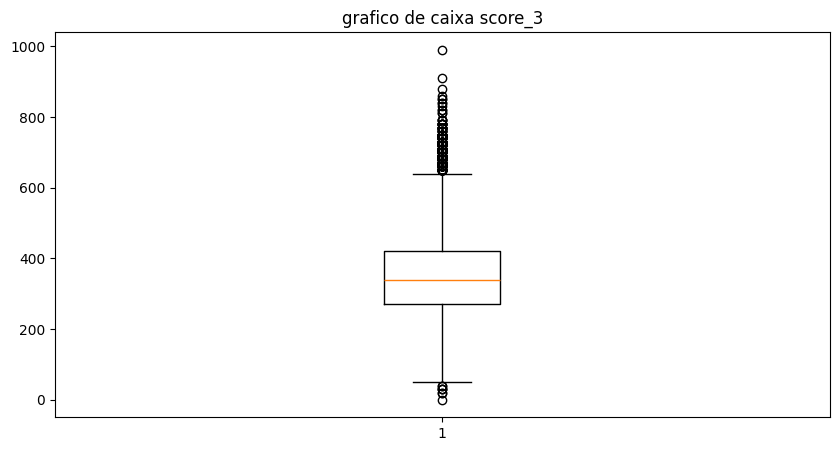

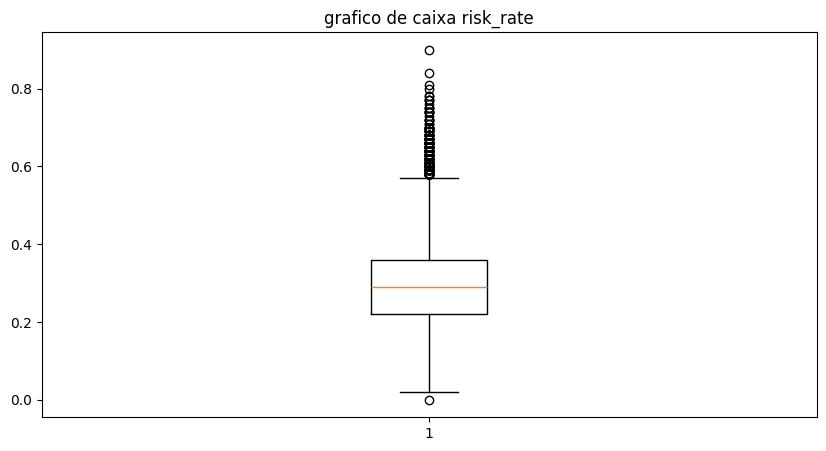

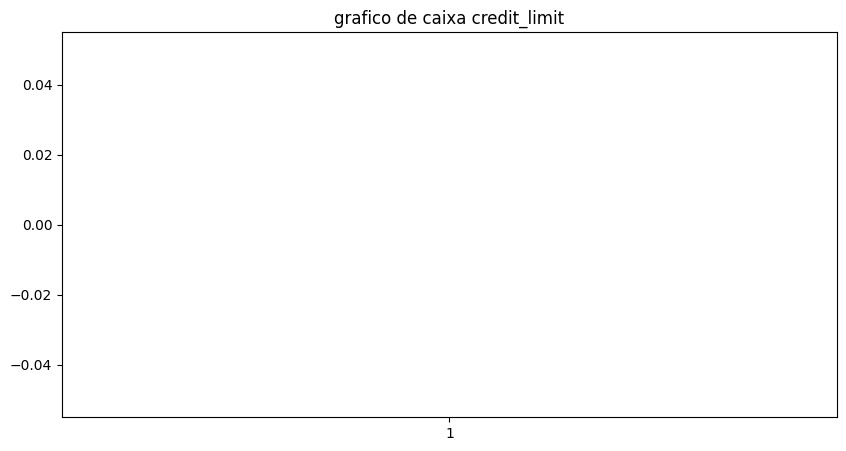

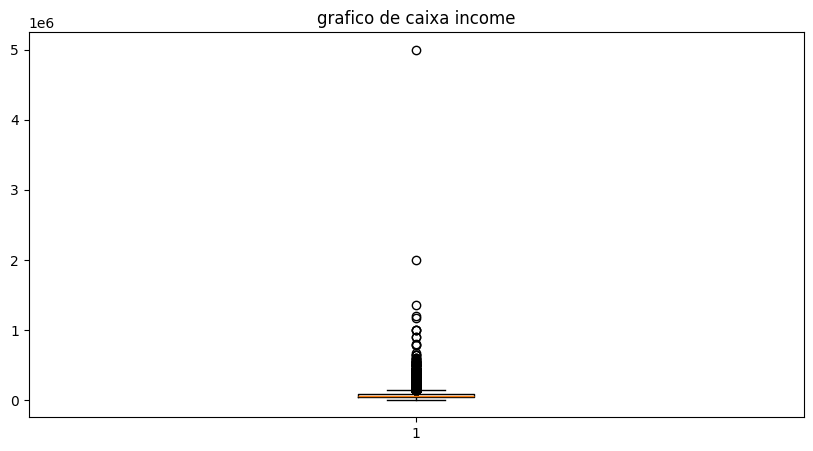

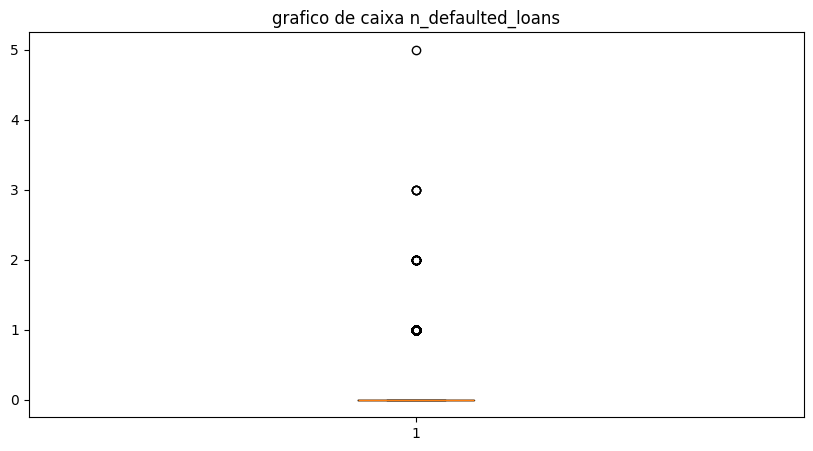

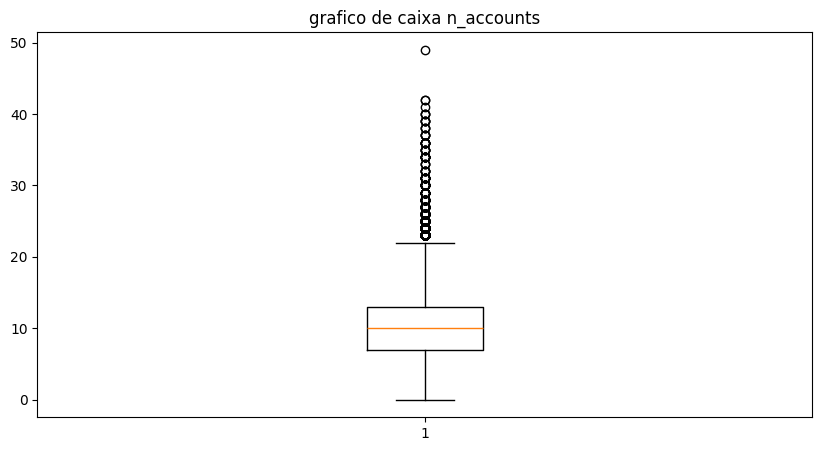

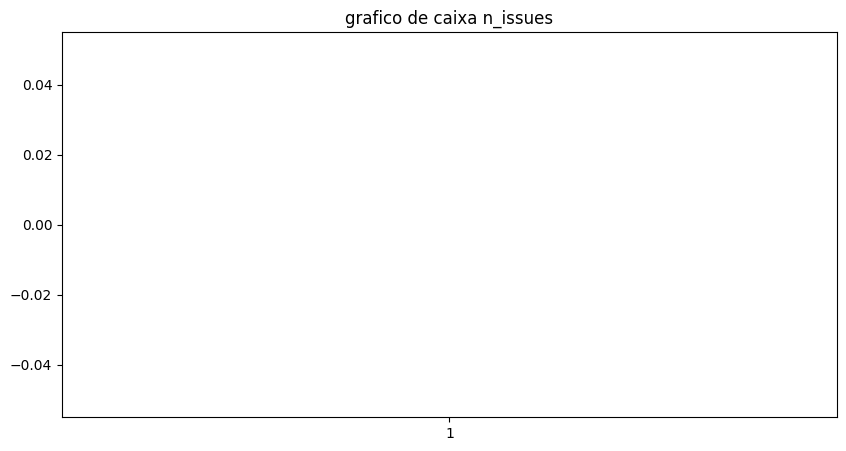

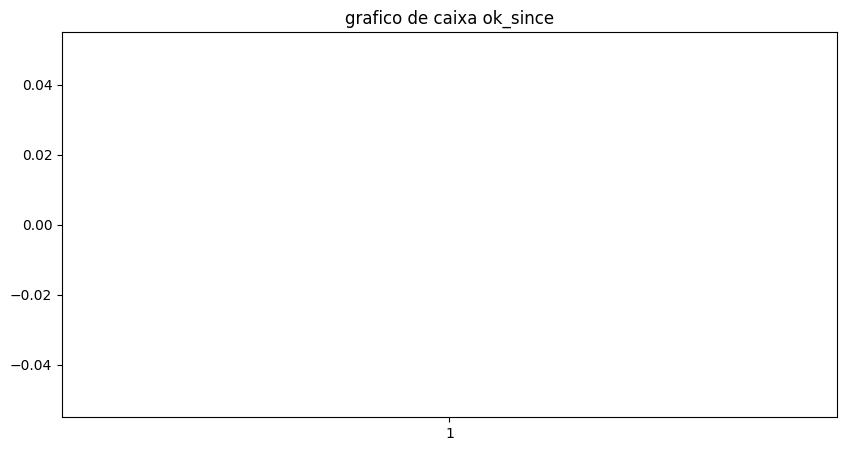

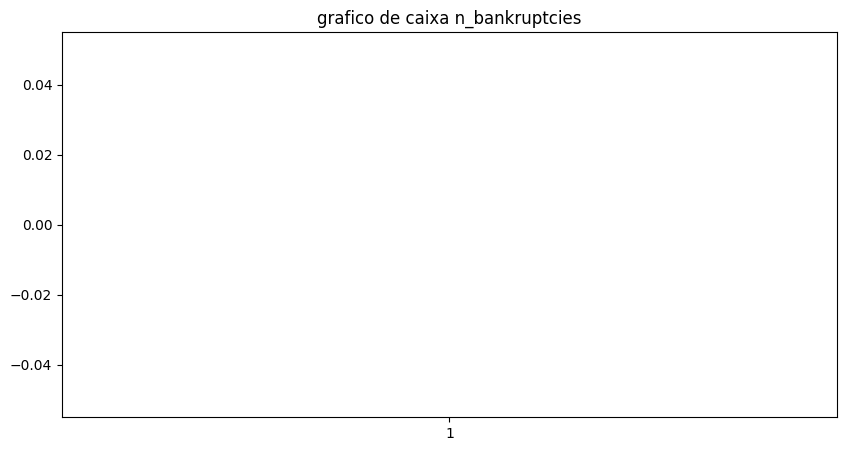

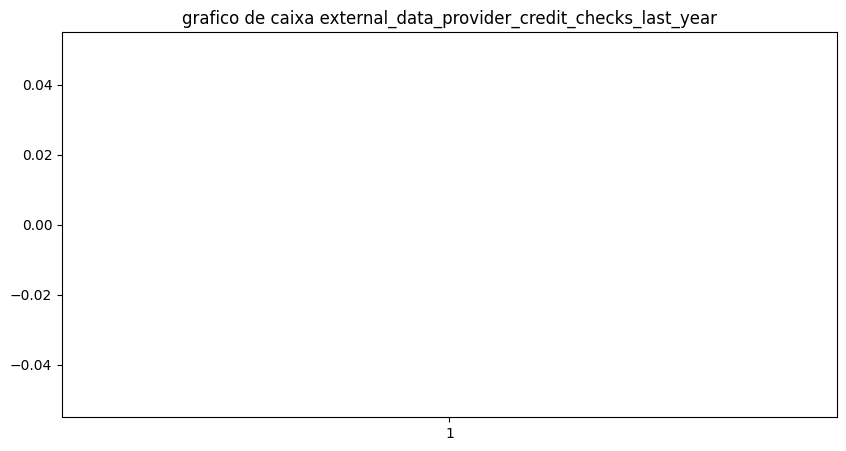

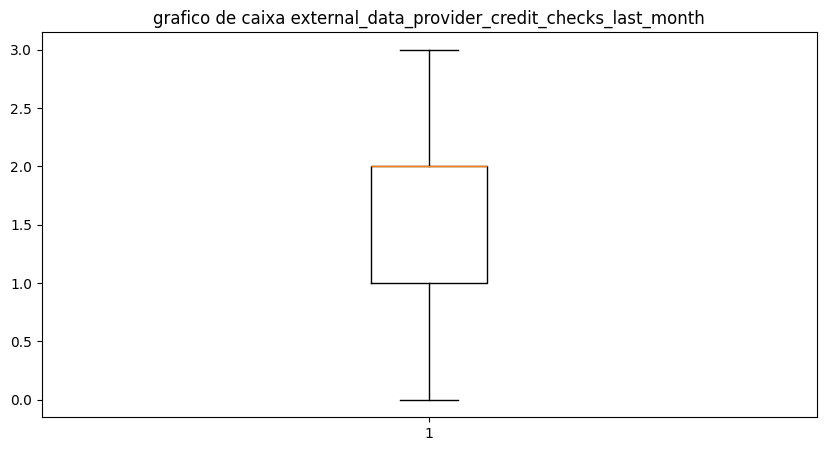

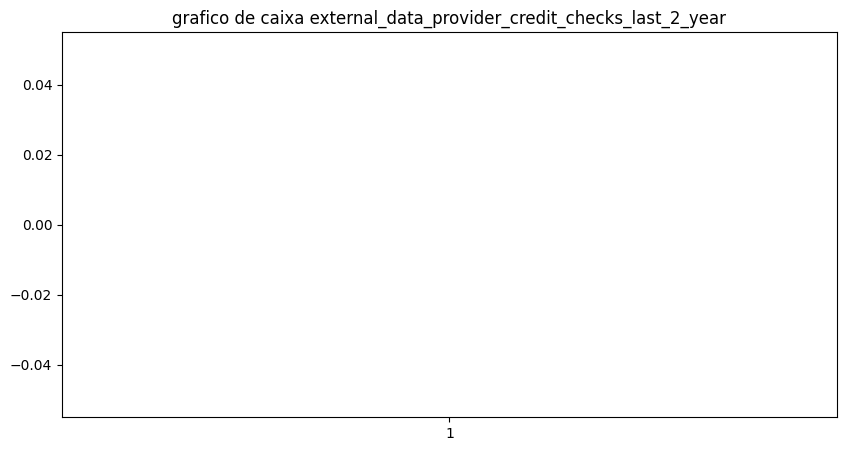

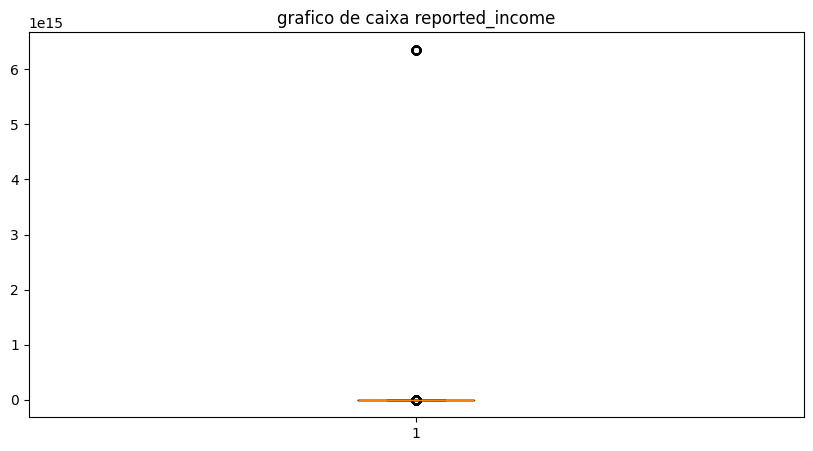

In [13]:
# plotando graficos de caixa
for box in num_col:
    plt.figure(figsize=(10,5))
    plt.title(f'grafico de caixa {box}')
    plt.boxplot(df2[box])

Winsorizaçao 


In [14]:
# criando funcao winsorize para tratar outliers
columns_for_win = ['n_accounts', 'income', 'score_3']
def func_winsorize(df, columns, lower, upper):
    """
    essa funcao aplica o metodo winsorize em colunas selecionadas de um dataframe em uma lista
    upper: limite superior dos dados
    lower: limite inferior """
    
    for col in columns:
        mean_ = np.mean(df[col])
        print(f'media da coluna {col} antes de winsorized: {mean_}')
    print('---'*40)
    for col in columns:
        df[col] = np.array(winsorize(df[col], limits=(lower, upper)))
        mean = np.mean(df[col])
        print(f'media da coluna {col} pós winsorized: {mean}')
    return df

In [15]:
df2 = func_winsorize(df=df2, columns=columns_for_win, lower=0.01, upper=0.01)
display(df2)

media da coluna n_accounts antes de winsorized: 10.696731643632107
media da coluna income antes de winsorized: 71607.22713928782
media da coluna score_3 antes de winsorized: 348.01220006302617
------------------------------------------------------------------------------------------------------------------------
media da coluna n_accounts pós winsorized: 10.670800882366182
media da coluna income pós winsorized: 70495.19870323685
media da coluna score_3 pós winsorized: 347.683338585513


,target_default,score_3,risk_rate,credit_limit,income,n_defaulted_loans,n_accounts,n_issues,ok_since,n_bankruptcies,external_data_provider_credit_checks_last_year,external_data_provider_credit_checks_last_month,external_data_provider_credit_checks_last_2_year,reported_income
0,False,350.0,0.40,0.0,65014.12,0.0,18.0,18.0,NaN,0.0,0.0,2,NaN,57849.0
1,False,370.0,0.24,39726.0,100018.91,0.0,14.0,14.0,50.0,0.0,0.0,1,0.0,4902.0
2,True,360.0,0.29,NaN,65023.65,0.0,10.0,NaN,NaN,0.0,NaN,2,NaN,163679.0
3,False,510.0,0.32,54591.0,68830.01,0.0,19.0,19.0,NaN,1.0,NaN,3,NaN,1086.0
4,False,500.0,0.18,NaN,60011.29,0.0,11.0,NaN,NaN,0.0,1.0,2,0.0,198618.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44995,False,280.0,0.17,10627.0,100013.24,0.0,7.0,7.0,37.0,0.0,1.0,2,0.0,73417.0
44996,False,370.0,0.27,36262.0,95026.69,0.0,16.0,16.0,NaN,0.0,NaN,1,NaN,26246.0
44997,False,280.0,0.30,0.0,106020.90,0.0,6.0,6.0,7.0,0.0,1.0,2,NaN,101252.0
44998,True,240.0,0.37,0.0,185018.07,0.0,10.0,10.0,53.0,0.0,1.0,0,0.0,129844.0


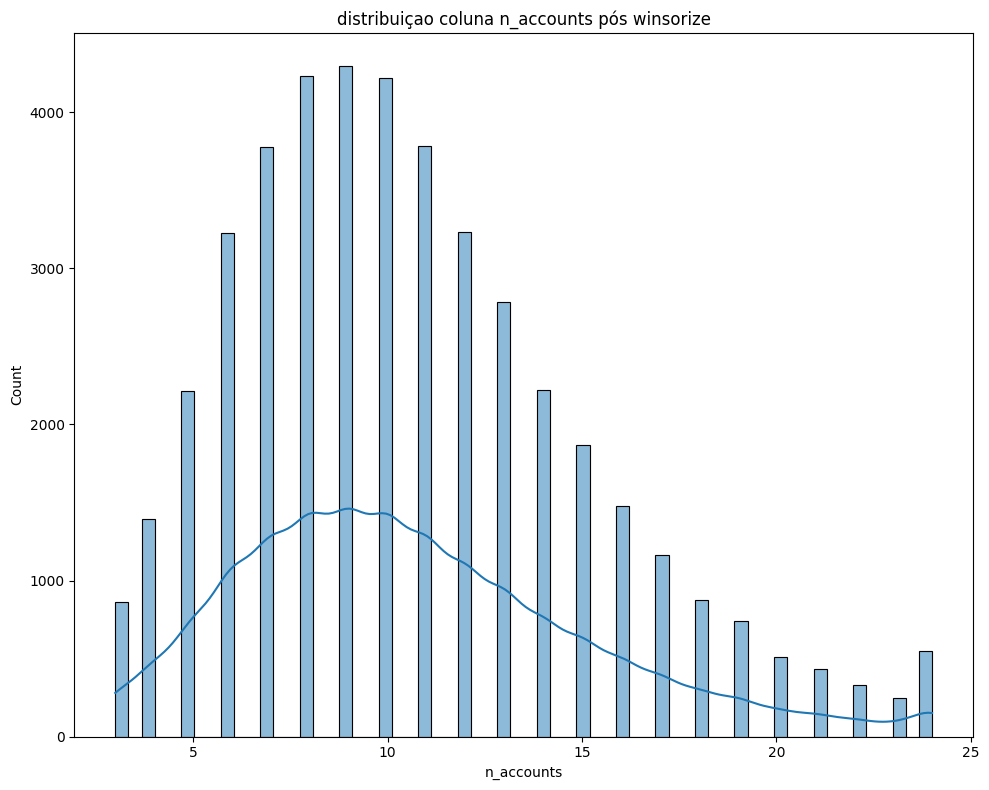

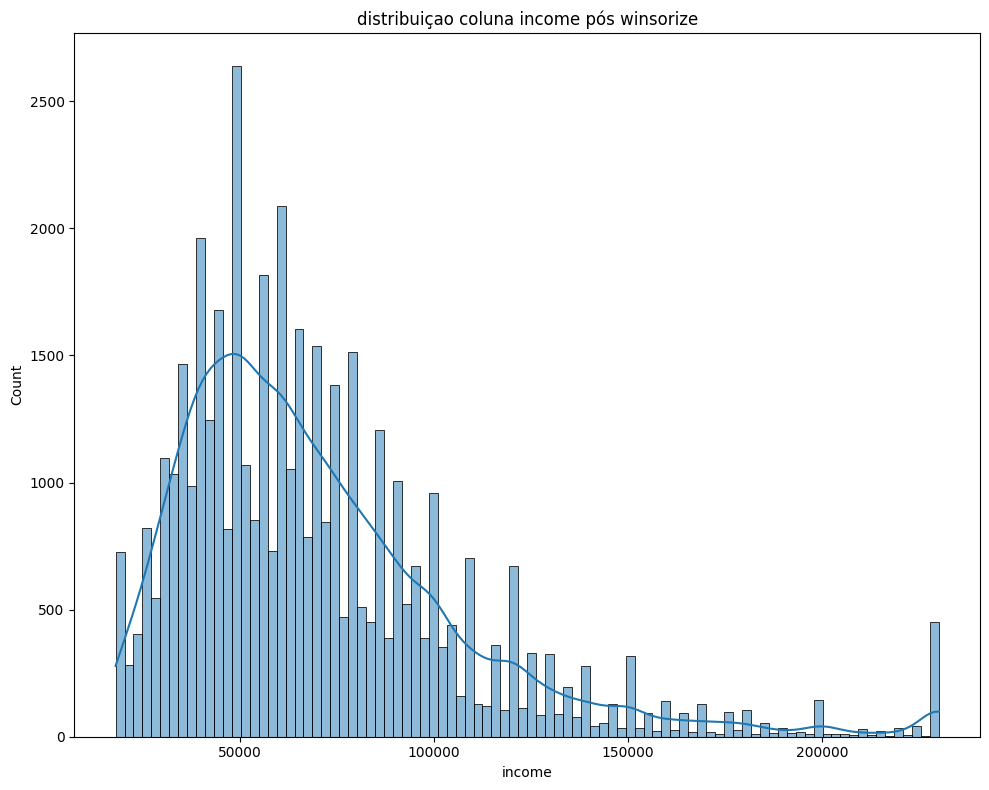

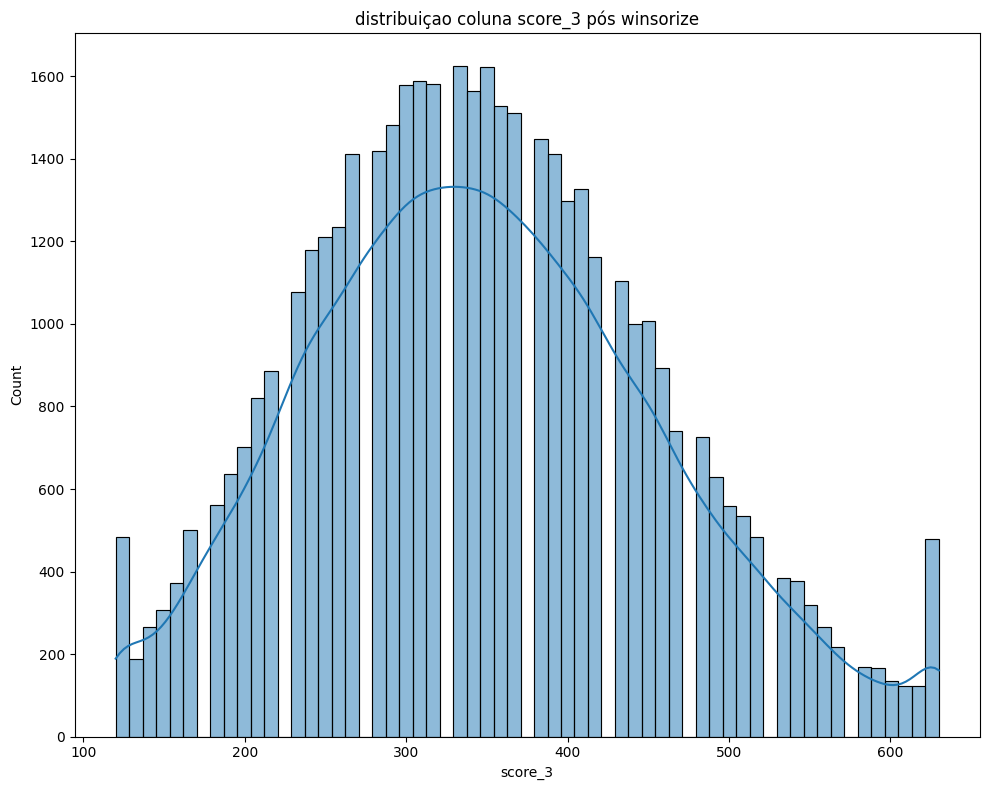

In [16]:
# vizualizando nova distribuiçao 
for new_distri in columns_for_win:
    plt.figure(figsize=(10,8))
    plt.title(f'distribuiçao coluna {new_distri} pós winsorize')
    sns.histplot(df2[new_distri], kde=True, edgecolor='black')
    plt.tight_layout()
    plt.show()

In [17]:
df2.isnull().sum()

target_default                                       2697
score_3                                                 0
risk_rate                                               0
credit_limit                                        13226
income                                                  0
n_defaulted_loans                                       0
n_accounts                                              0
n_issues                                            10970
ok_since                                            25983
n_bankruptcies                                        123
external_data_provider_credit_checks_last_year      14906
external_data_provider_credit_checks_last_month         0
external_data_provider_credit_checks_last_2_year    22348
reported_income                                         0
dtype: int64

In [18]:
# para nao enviesar a analise e uma possivel modelagem como valores fora da realidade, vamos substituir os valores pela sua mediana, criando assim um comportamneto medio
median_values = ['credit_limit', 'n_issues', 'ok_since']
df2[median_values] = df2[median_values].fillna(df2[median_values].median())


In [19]:
df2.isnull().sum()

target_default                                       2697
score_3                                                 0
risk_rate                                               0
credit_limit                                            0
income                                                  0
n_defaulted_loans                                       0
n_accounts                                              0
n_issues                                                0
ok_since                                                0
n_bankruptcies                                        123
external_data_provider_credit_checks_last_year      14906
external_data_provider_credit_checks_last_month         0
external_data_provider_credit_checks_last_2_year    22348
reported_income                                         0
dtype: int64

In [20]:
# retirando valores nulos da coluna target_default
df2 = df2[df2['target_default'].notna()]
df2.isnull().sum()

target_default                                          0
score_3                                                 0
risk_rate                                               0
credit_limit                                            0
income                                                  0
n_defaulted_loans                                       0
n_accounts                                              0
n_issues                                                0
ok_since                                                0
n_bankruptcies                                        123
external_data_provider_credit_checks_last_year      14015
external_data_provider_credit_checks_last_month         0
external_data_provider_credit_checks_last_2_year    21021
reported_income                                         0
dtype: int64

In [21]:
# transformando 'target_default' de bolean para int
df2['target_default'] = df2['target_default'].replace(to_replace=True, value=1)
df2['target_default'] = df2['target_default'].replace(to_replace=False, value=0)

In [22]:
df2['target_default'].value_counts()

target_default
0    35069
1     6660
Name: count, dtype: int64

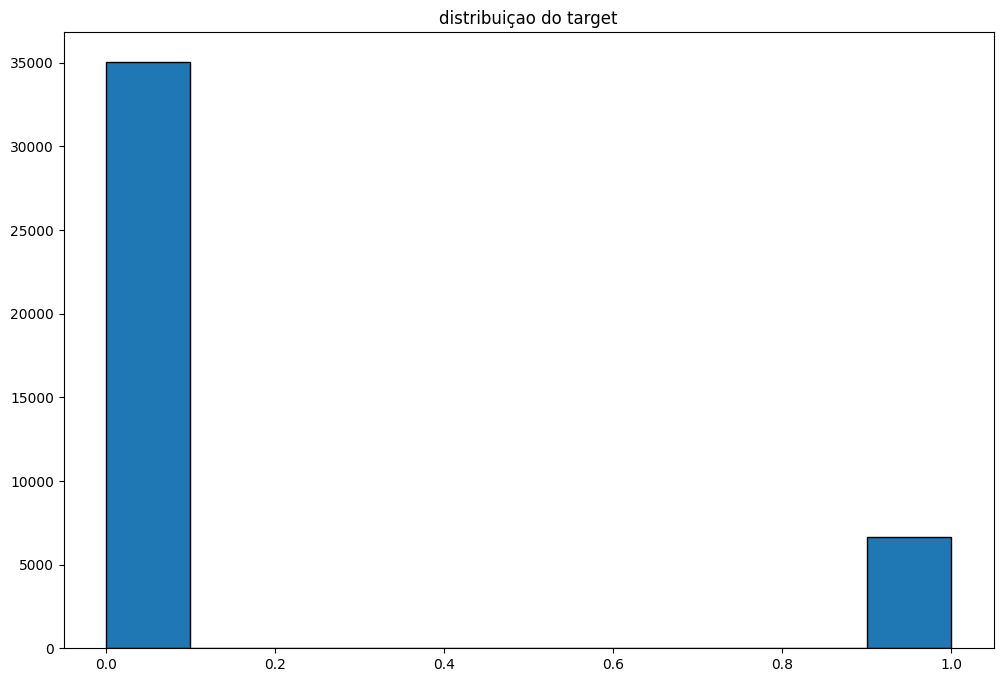

In [23]:
# distribuiçao do target
plt.figure(figsize=(12,8))
plt.title('distribuiçao do target')
plt.hist(df2['target_default'], edgecolor='black')
plt.show()

In [24]:
# tratando problema de inf na coluna reported_income
df2['reported_income'].max()
df2['reported_income'] = df2['reported_income'].replace([np.inf, -np.inf], np.nan)

In [25]:
# vizualizando quantidade de dados nulos pós tratamento 
report_income_nan = df2['reported_income'].isnull().sum()
print(f'quantidade de dados nulos: {report_income_nan}')

quantidade de dados nulos: 66


In [26]:
# dropando dados nulos em reported_income
df2['reported_income'] = df2['reported_income'].notna()
df2['reported_income'].isnull().sum()

0

In [27]:
# substituindo valor boleano por 0 e 1
df2['reported_income'] = df2['reported_income'].replace(to_replace=True, value=1)
df2['reported_income'] = df2['reported_income'].replace(to_replace=False, value=0)


In [28]:
df2['reported_income'].value_counts()

reported_income
1    41663
0       66
Name: count, dtype: int64

In [29]:
# retirando valores nulos de 'n_bankruptcies'
df2 = df2[df['n_bankruptcies'].notna()]

In [30]:
df2.isnull().sum()

target_default                                          0
score_3                                                 0
risk_rate                                               0
credit_limit                                            0
income                                                  0
n_defaulted_loans                                       0
n_accounts                                              0
n_issues                                                0
ok_since                                                0
n_bankruptcies                                          0
external_data_provider_credit_checks_last_year      13966
external_data_provider_credit_checks_last_month         0
external_data_provider_credit_checks_last_2_year    20964
reported_income                                         0
dtype: int64

In [31]:
df['external_data_provider_credit_checks_last_year'].describe()

count    29876.000000
mean         0.503381
std          0.499997
min          0.000000
25%          0.000000
50%          1.000000
75%          1.000000
max          1.000000
Name: external_data_provider_credit_checks_last_year, dtype: float64

In [32]:
df['external_data_provider_credit_checks_last_year'].value_counts()

external_data_provider_credit_checks_last_year
1.0    15039
0.0    14837
Name: count, dtype: int64

In [33]:
# criando funcao para inputaçao usando ML
def fill_binary_column(df, column):
    df_known = df[df[column].notna()]
    df_unknown = df[df[column].isna()]
    if df_unknown.empty:
        print('nao ha valores nulos para preencher')
        return df
    x_train = df_known.drop(column, axis=1)
    y_train = df_known[column]

    # usando modelo diretamente
    model = HistGradientBoostingClassifier(max_iter=200)
    model.fit(x_train, y_train)
    print(f'metrica no treino coluna {column}: {model.score(x_train, y_train):.4f}')
    x_unknown = df_unknown.drop(column, axis=1)
    y_pred = model.predict(x_unknown)

    # preencher apenas os NaN
    df.loc[df[column].isna(), column] = y_pred
    return df


In [34]:
df2.isnull().sum()

target_default                                          0
score_3                                                 0
risk_rate                                               0
credit_limit                                            0
income                                                  0
n_defaulted_loans                                       0
n_accounts                                              0
n_issues                                                0
ok_since                                                0
n_bankruptcies                                          0
external_data_provider_credit_checks_last_year      13966
external_data_provider_credit_checks_last_month         0
external_data_provider_credit_checks_last_2_year    20964
reported_income                                         0
dtype: int64

In [35]:
# preeencher as colunas diretamente
fill_columns = ['external_data_provider_credit_checks_last_year', 'external_data_provider_credit_checks_last_2_year']
def fill_nan(df, columns):
    for fill in fill_columns:
        df = fill_binary_column(df2, fill)
    return df
df2 = fill_nan(df2, fill_columns)
display(df2)

  File "C:\Users\souza\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\joblib\externals\loky\backend\context.py", line 282, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


metrica no treino coluna external_data_provider_credit_checks_last_year: 0.5461
metrica no treino coluna external_data_provider_credit_checks_last_2_year: 1.0000


,target_default,score_3,risk_rate,credit_limit,income,n_defaulted_loans,n_accounts,n_issues,ok_since,n_bankruptcies,external_data_provider_credit_checks_last_year,external_data_provider_credit_checks_last_month,external_data_provider_credit_checks_last_2_year,reported_income
0,0,350.0,0.40,0.0,65014.12,0.0,18.0,18.0,32.0,0.0,0.0,2,0.0,1
1,0,370.0,0.24,39726.0,100018.91,0.0,14.0,14.0,50.0,0.0,0.0,1,0.0,1
2,1,360.0,0.29,25647.0,65023.65,0.0,10.0,10.0,32.0,0.0,1.0,2,0.0,1
3,0,510.0,0.32,54591.0,68830.01,0.0,19.0,19.0,32.0,1.0,0.0,3,0.0,1
4,0,500.0,0.18,25647.0,60011.29,0.0,11.0,10.0,32.0,0.0,1.0,2,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44995,0,280.0,0.17,10627.0,100013.24,0.0,7.0,7.0,37.0,0.0,1.0,2,0.0,1
44996,0,370.0,0.27,36262.0,95026.69,0.0,16.0,16.0,32.0,0.0,1.0,1,0.0,1
44997,0,280.0,0.30,0.0,106020.90,0.0,6.0,6.0,7.0,0.0,1.0,2,0.0,1
44998,1,240.0,0.37,0.0,185018.07,0.0,10.0,10.0,53.0,0.0,1.0,0,0.0,1


Analise Multivariada

In [36]:
df2.head()

,target_default,score_3,risk_rate,credit_limit,income,n_defaulted_loans,n_accounts,n_issues,ok_since,n_bankruptcies,external_data_provider_credit_checks_last_year,external_data_provider_credit_checks_last_month,external_data_provider_credit_checks_last_2_year,reported_income
0,0,350.0,0.40,0.0,65014.12,0.0,18.0,18.0,32.0,0.0,0.0,2,0.0,1
1,0,370.0,0.24,39726.0,100018.91,0.0,14.0,14.0,50.0,0.0,0.0,1,0.0,1
2,1,360.0,0.29,25647.0,65023.65,0.0,10.0,10.0,32.0,0.0,1.0,2,0.0,1
3,0,510.0,0.32,54591.0,68830.01,0.0,19.0,19.0,32.0,1.0,0.0,3,0.0,1
4,0,500.0,0.18,25647.0,60011.29,0.0,11.0,10.0,32.0,0.0,1.0,2,0.0,1


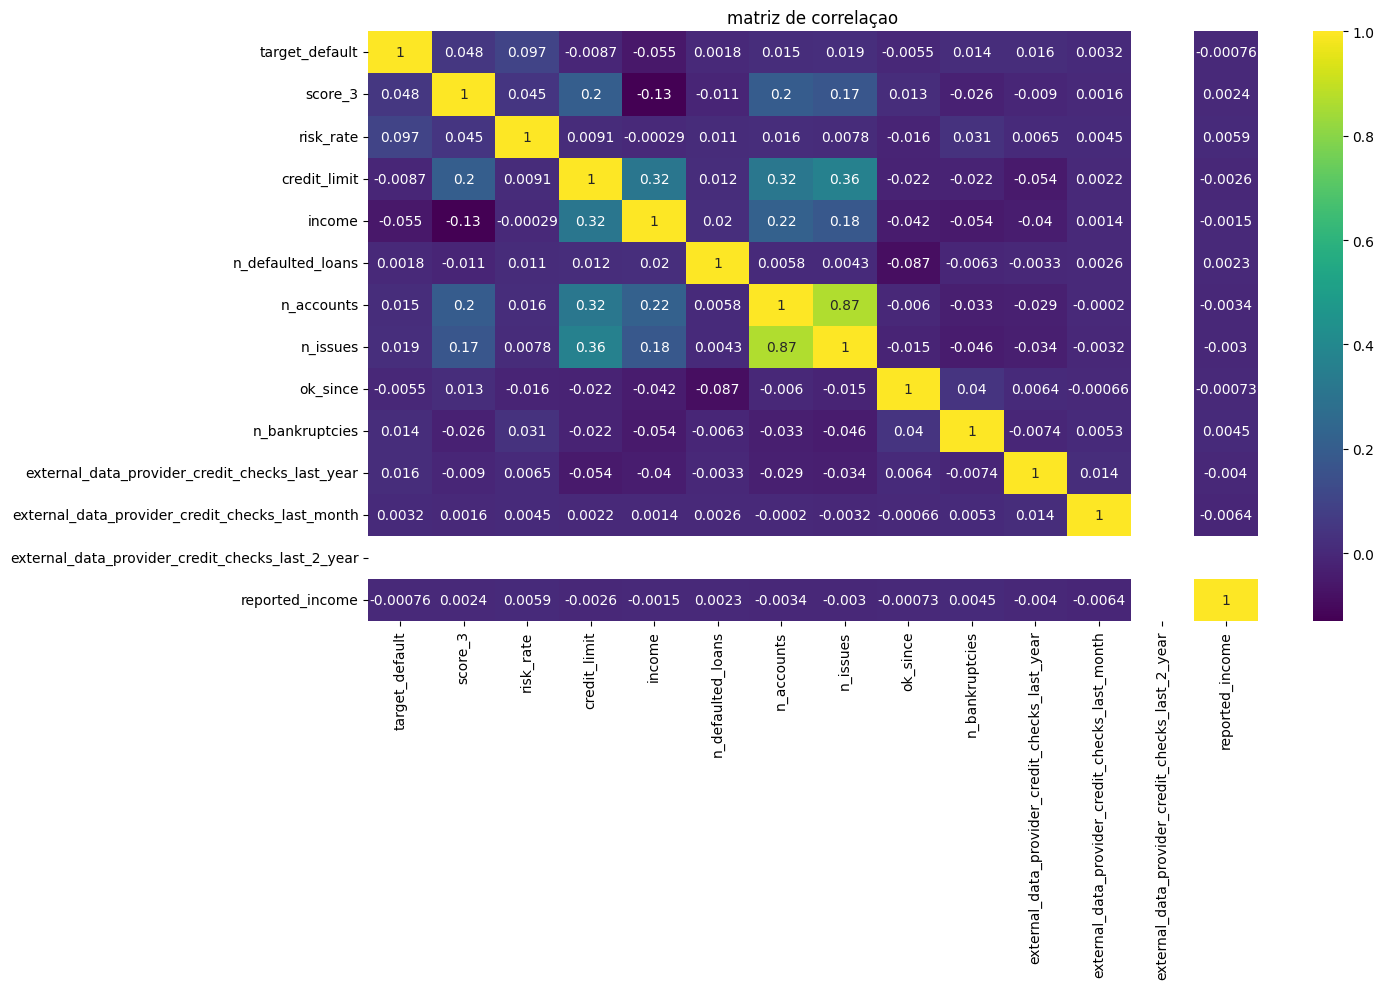

In [37]:
# plotando matriz de correlação 
plt.figure(figsize=(15,10))
plt.title('matriz de correlaçao')
sns.heatmap(df2.corr(), annot=True, cbar=True, cmap='viridis')
plt.tight_layout()
plt.show()

In [38]:
# criação de nova coluna categoria com base ao score
def score_rating(score):
    if score < 400:
        return 'low'
    elif 400 <= score <= 500:
        return 'medium'
    elif 501 <= score <= 650:
        return 'good'
    else:
        return 'excellent'
df2['score_rating'] = df2['score_3'].apply(score_rating)



In [39]:
# vizualizando linhas que contem scores excelentes
df2['score_rating'].value_counts()

score_rating
low       28461
medium     9694
good       3451
Name: count, dtype: int64

In [40]:
df2['score_rating'].value_counts()

score_rating
low       28461
medium     9694
good       3451
Name: count, dtype: int64

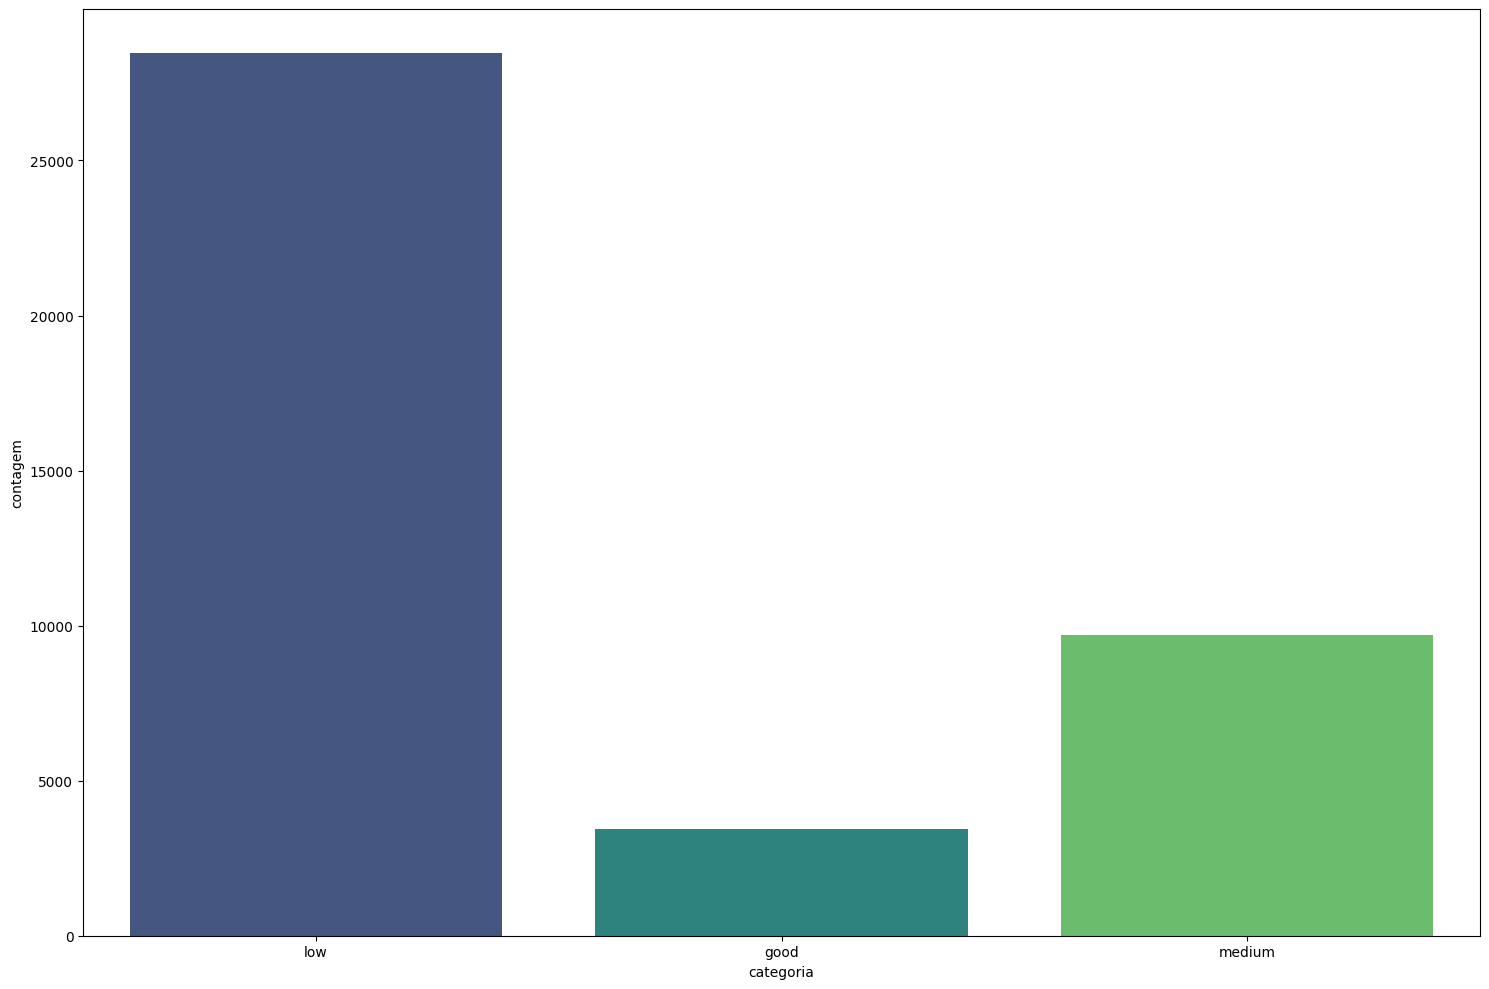

In [41]:
# vizualizando nova categoria 
plt.figure(figsize=(15,10))
sns.countplot(x = df2['score_rating'], palette='viridis')
plt.xlabel('categoria')
plt.ylabel('contagem')
plt.tight_layout()
plt.show()

Entendendo comportamento da nova categoria 

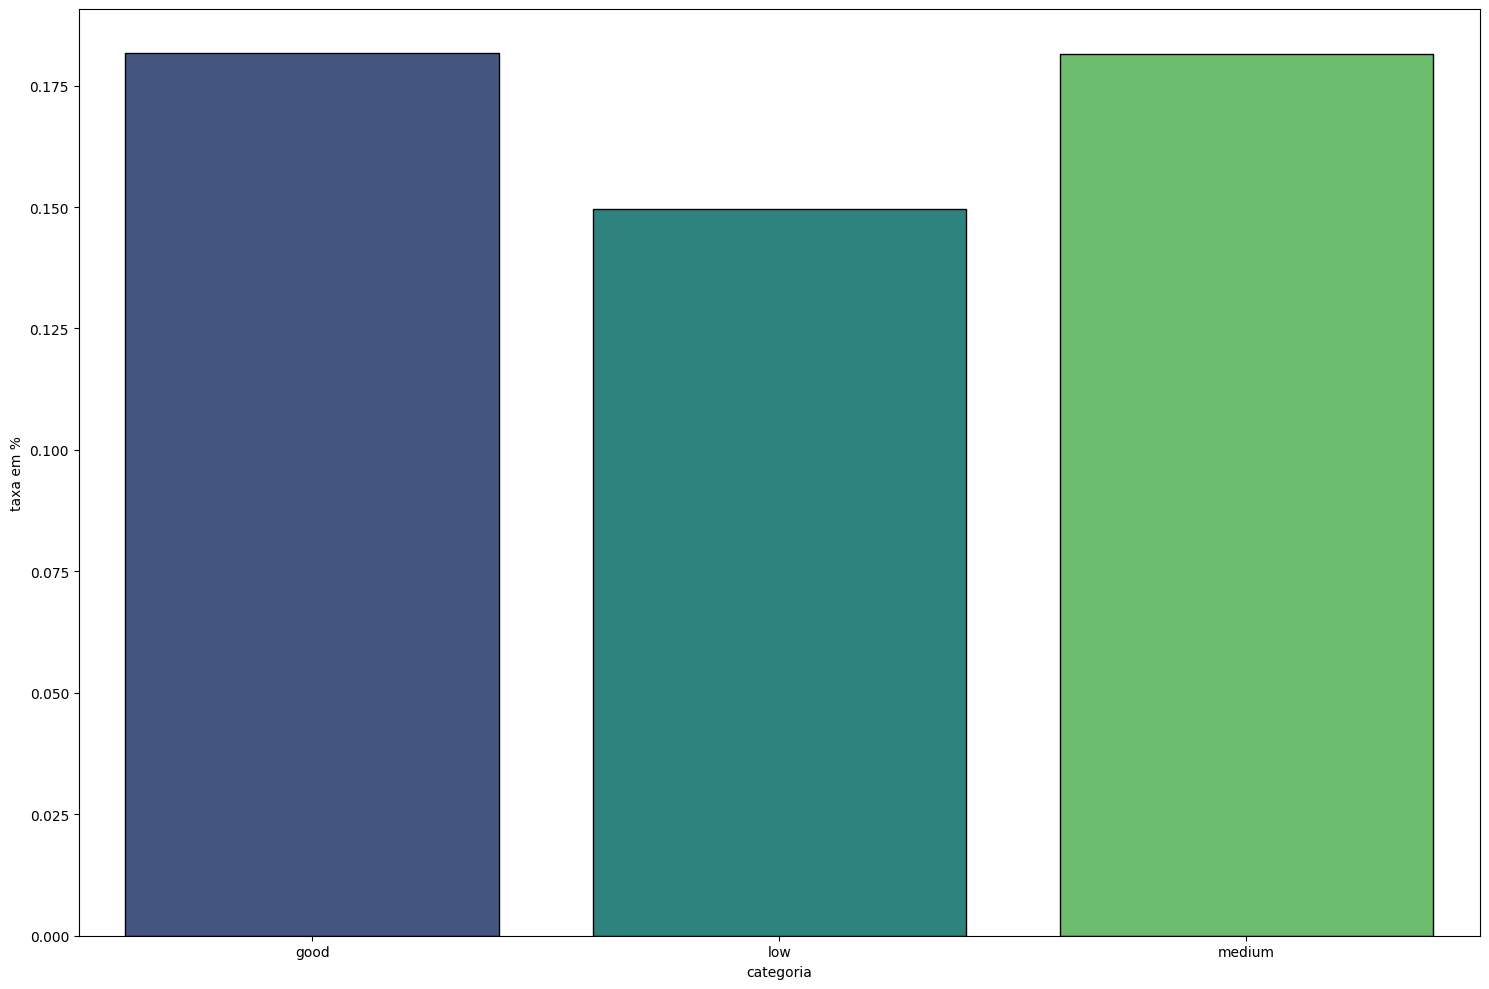

In [42]:
# taxa de cura entre os score_rating
cure  = df2.groupby('score_rating')['target_default'].mean().reset_index()
plt.figure(figsize=(15,10))
sns.barplot(data=cure, x='score_rating', y='target_default', palette='viridis', edgecolor='black')
plt.xlabel('categoria')
plt.ylabel('taxa em %')
plt.tight_layout()
plt.show()

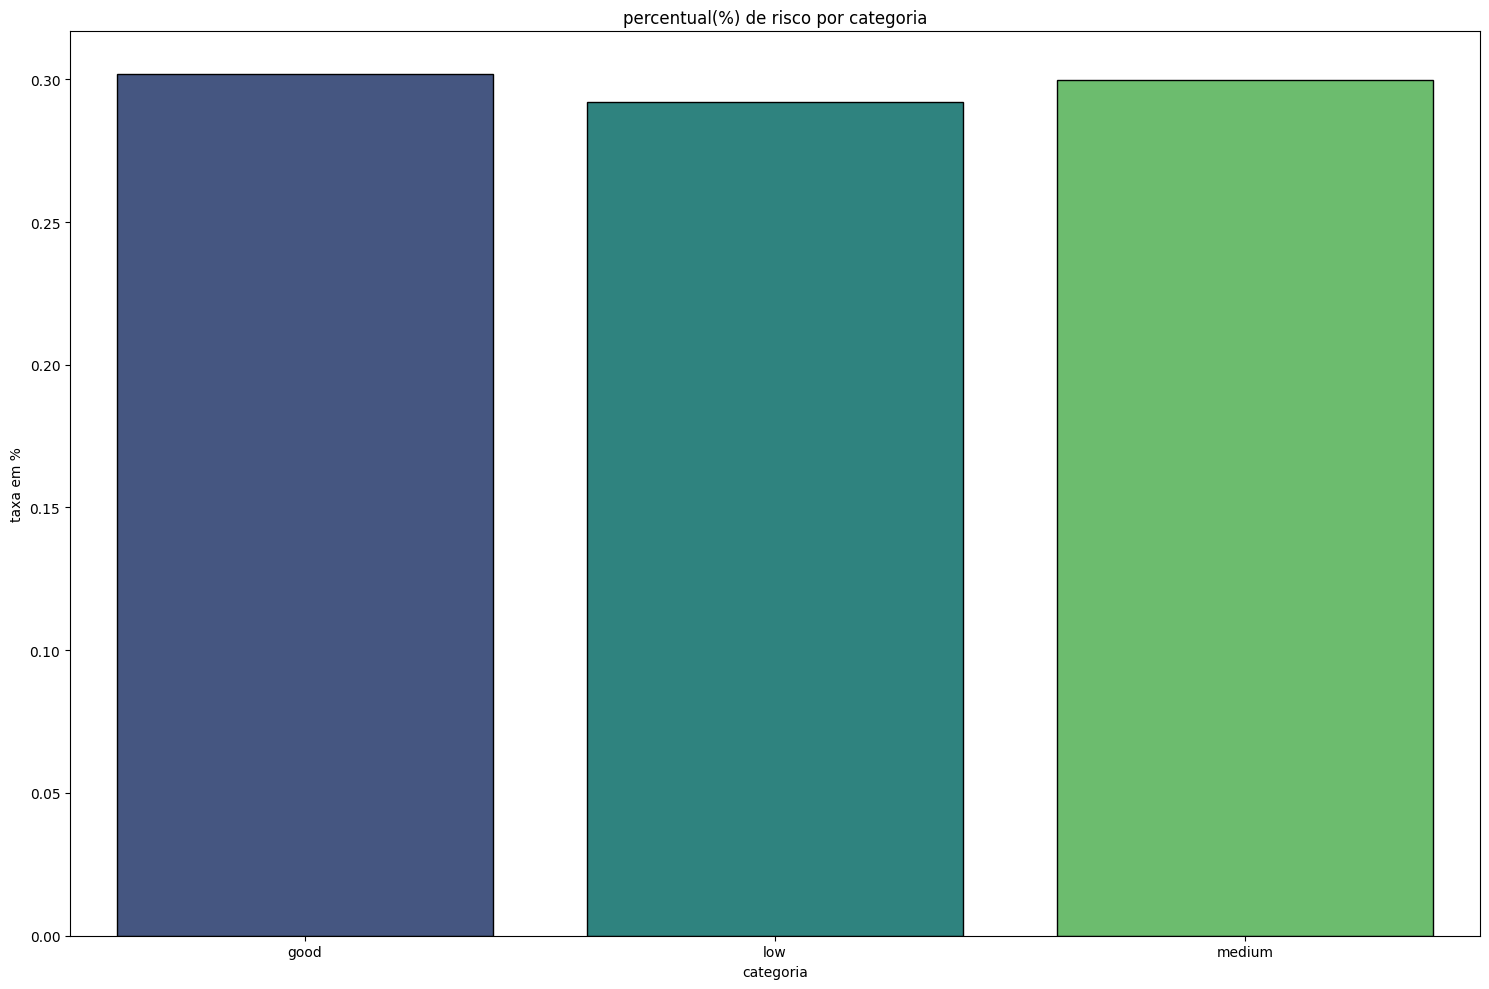

In [43]:
# percentual de risco por categorias
risk_cat = df2.groupby('score_rating')['risk_rate'].mean().reset_index()
plt.figure(figsize=(15,10))
plt.title('percentual(%) de risco por categoria')
sns.barplot(data=risk_cat, x='score_rating', y='risk_rate', edgecolor='black', palette='viridis')
plt.xlabel('categoria')
plt.ylabel('taxa em %')
plt.tight_layout()
plt.show()

In [44]:
# criando nova coluna rating_score_enc para nova matriz de correlação
le = LabelEncoder()
df2['score_rating_enc'] = le.fit_transform(df2['score_rating'])

In [45]:
# criando novo objeto df excluindo antiga coluna score_rating
df2_enc = df2.drop('score_rating', axis=1)

<Axes: >

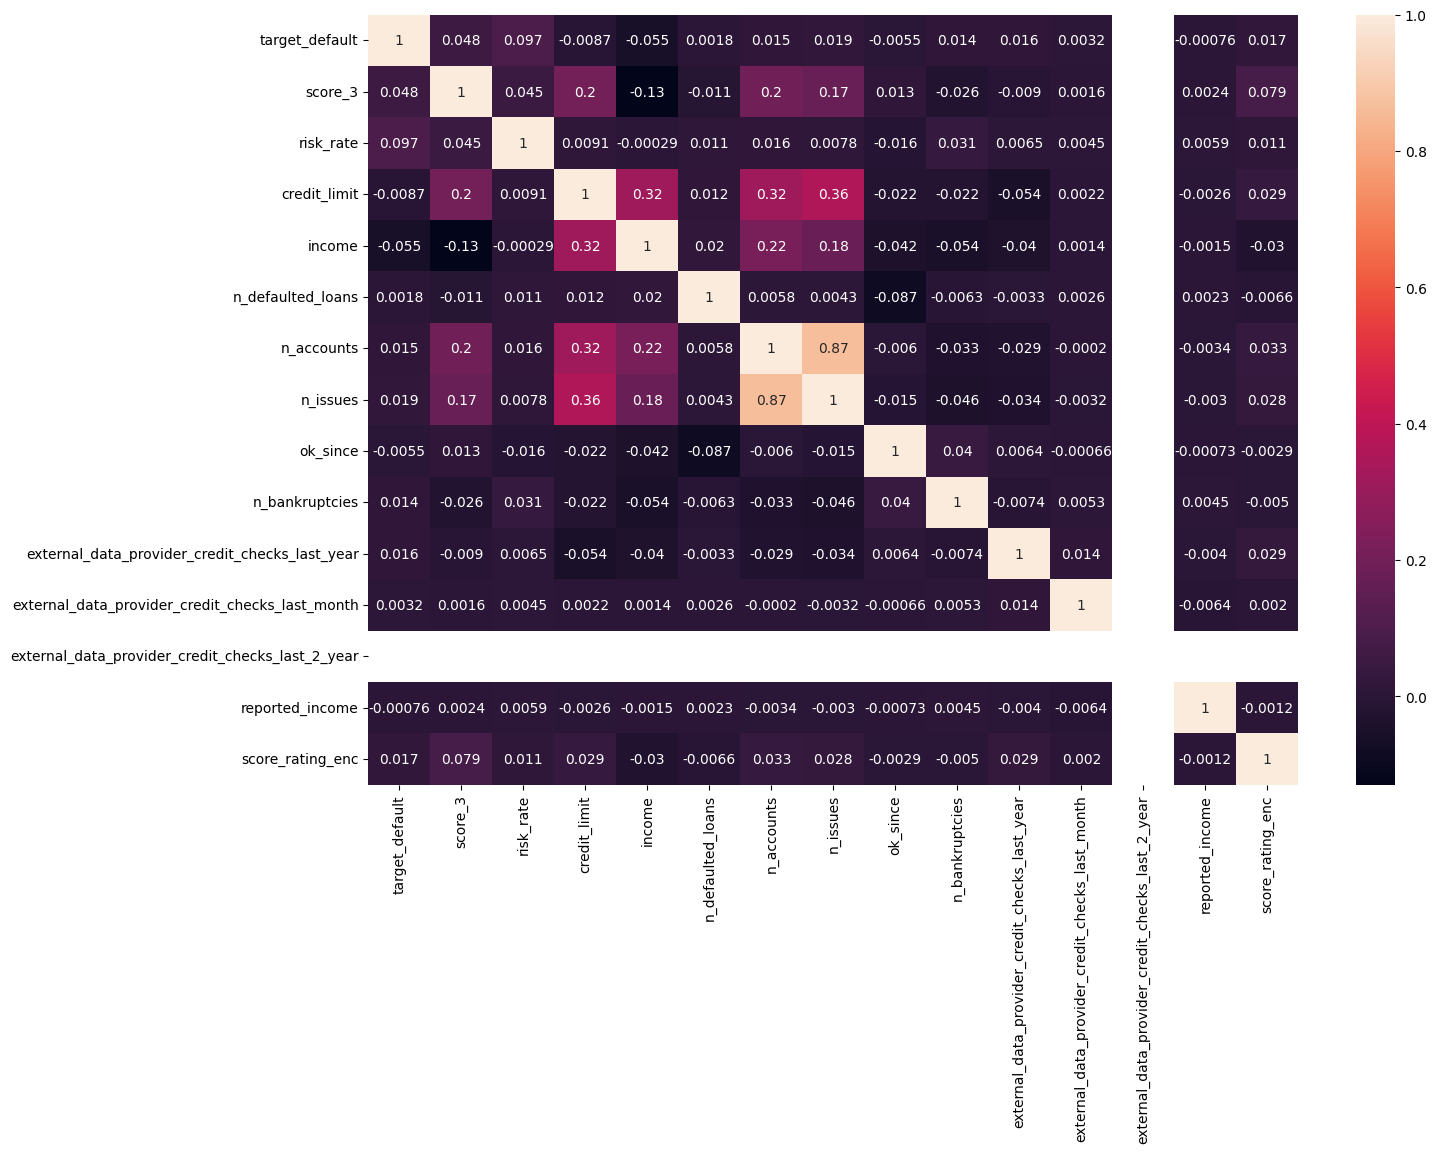

In [46]:
# nova matriz de correlação
plt.figure(figsize=(15,10))
sns.heatmap(df2_enc.corr(), annot=True)

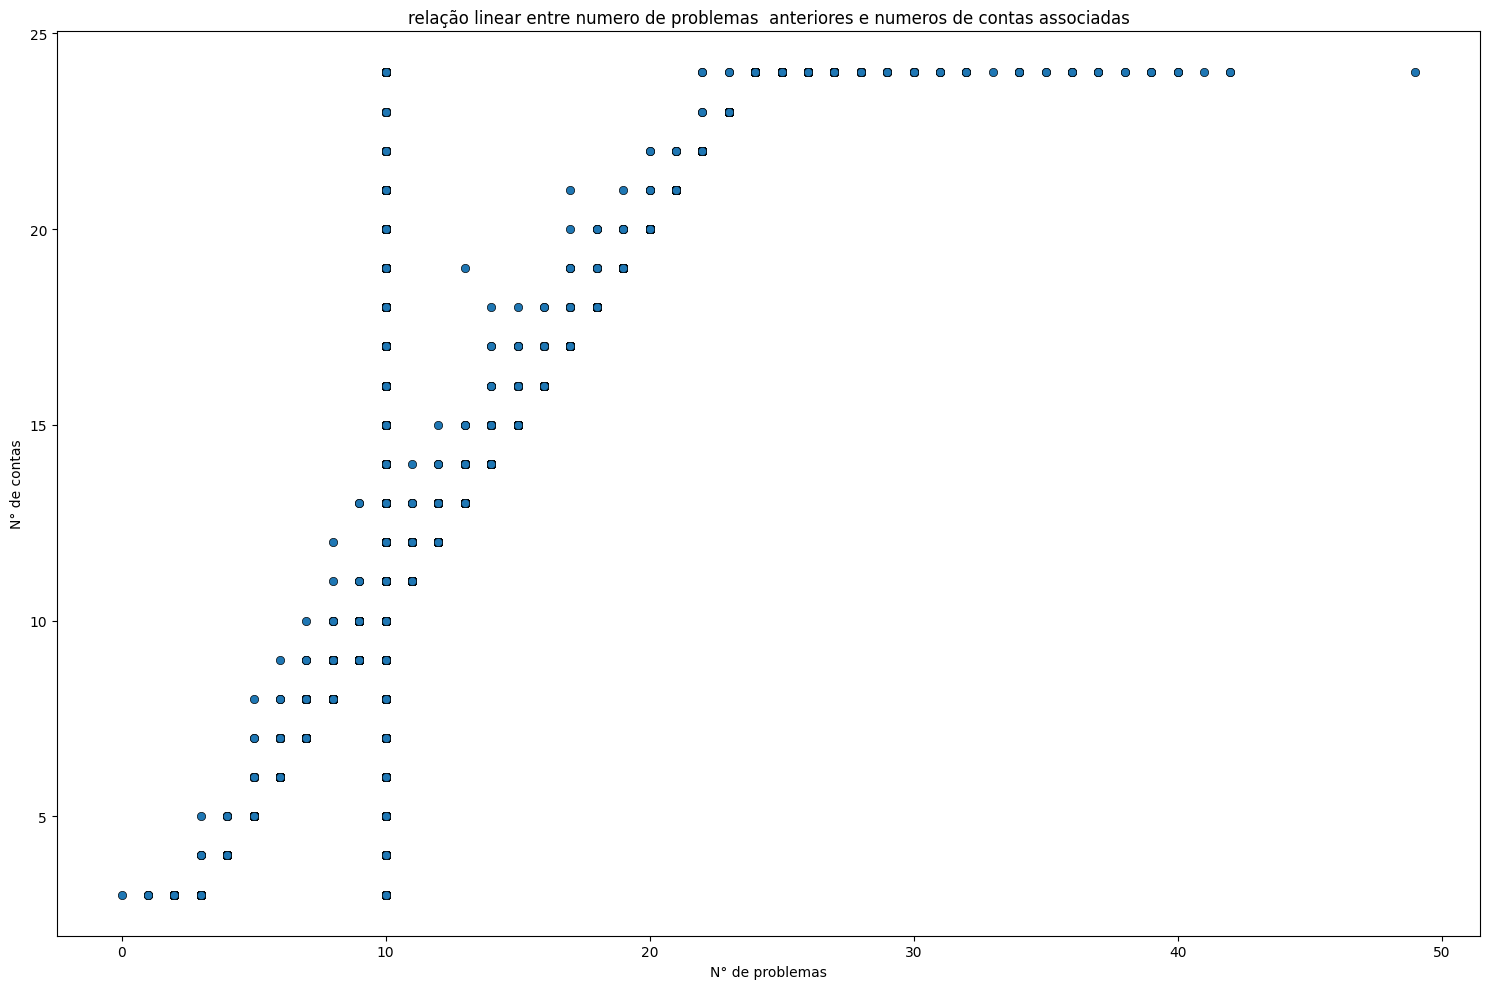

In [47]:
# entendendo a relação linear entre numero de contas e numeros de problemas (inadimplencias)
plt.figure(figsize=(15,10))
plt.title('relação linear entre numero de problemas  anteriores e numeros de contas associadas')
sns.scatterplot(x=df2['n_issues'], y=df2['n_accounts'], edgecolor='black')
plt.xlabel('N° de problemas')
plt.ylabel('N° de contas')
plt.tight_layout()
plt.show()

Por praticamente indicar a mesma informaçao, irei dropar a coluna 'n_accounts'

In [48]:
df2 = df2.drop('n_accounts', axis=1)

 A relação entre numeros de inadimplecias e numeros de contas associadas é quase linear!
 

In [49]:
# vizualizando o cliente com o maior risco de inadimplencia da base de dados
max(df2['risk_rate'])

0.9

In [50]:
df2[df2['risk_rate']==0.9]

,target_default,score_3,risk_rate,credit_limit,income,n_defaulted_loans,n_issues,ok_since,n_bankruptcies,external_data_provider_credit_checks_last_year,external_data_provider_credit_checks_last_month,external_data_provider_credit_checks_last_2_year,reported_income,score_rating,score_rating_enc
25757,0,190.0,0.9,0.0,45019.31,0.0,9.0,36.0,0.0,1.0,1,0.0,1,low,1


O cliente com maior rating foi classificado como adimplente, muito por conta do tempo que se manteve 'limpo'. Indicando que a coluna 'ok_since' seja um otimo indicador para o nosso problema.

Estudo de Causalidade

Irei fazer um estudo causal simples apenas para entender a relaçao entre algumas variaveis que encontrei duvidas

Pergunta causal: “Quais variáveis realmente impactam o risco de inadimplência de um cliente, controlando por outras variáveis relevantes?”

In [51]:
# preparando base para estudo 
x_trat = 'n_issues'
y_out = 'target_default'
conf = ['score_3', 'credit_limit', 'n_defaulted_loans', 'ok_since']
cols = [x_trat , y_out] + conf
df_causal = df2[cols]
# setando x e y 
x = df_causal[[x_trat] + conf]
y = df_causal[y_out]

# adicionando intercepto 
x = sm.add_constant(x)

# treinando regressao logistica 
logit = sm.Logit(y,x)
# resultados 
results = logit.fit(disp=False)
print(results.summary())

                           Logit Regression Results                           
Dep. Variable:         target_default   No. Observations:                41606
Model:                          Logit   Df Residuals:                    41600
Method:                           MLE   Df Model:                            5
Date:                Wed, 20 Aug 2025   Pseudo R-squ.:                0.003433
Time:                        14:38:13   Log-Likelihood:                -18205.
converged:                       True   LL-Null:                       -18268.
Covariance Type:            nonrobust   LLR p-value:                 2.223e-25
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -2.1284      0.063    -33.670      0.000      -2.252      -2.004
n_issues              0.0135      0.004      3.787      0.000       0.007       0.020
score_3               0.

Conclusoes: 

 - n_defaulted_loans possui um coeficiente positivo, indicando que dívidas passadas podem aumentar o risco de inadimplência, mas o P-valor > 0.05 mostra que esse efeito não é estatisticamente significativo. Portanto, não podemos afirmar com confiança que dívidas passadas são um fator causal decisivo em um futuro modelo

- Variaveis como credit_limit e ok_since se mostram fatores positivos e com efeito estatistico comprovado para um futuro modelo, concluindo que sao caracteristicas sao sim decisisivas na modelagem (negativo para credit_limit → mais crédito diminui risco, negativo para ok_since → mais tempo como cliente diminui risco)

- n_issues é uma variavel importante, com seu coeficiente de 1%, ela impacta positivamente o modelo. Ou seja, quanto maior o numero de problemas, maior a probabilidade tende a um resultade positivo de inadimplencia. 

- score_3 nao influencia tanto como eu pensei, afirmando que nao é uma variavel significativa no problema



In [52]:
df2.columns

Index(['target_default', 'score_3', 'risk_rate', 'credit_limit', 'income',
       'n_defaulted_loans', 'n_issues', 'ok_since', 'n_bankruptcies',
       'external_data_provider_credit_checks_last_year',
       'external_data_provider_credit_checks_last_month',
       'external_data_provider_credit_checks_last_2_year', 'reported_income',
       'score_rating', 'score_rating_enc'],
      dtype='object')

Relaçao consultas pelo tempo x inadimplecia



Qual o efeito das variaveis external_data_provider_credit_checks_last_year, external_data_provider_credit_checks_last_month e  no alvo target_default? 

In [53]:
x_trat_ = ['external_data_provider_credit_checks_last_year', 'external_data_provider_credit_checks_last_month']
y_out_ = ['target_default']
#conf_ =  ['risk_rate', 'credit_limit', 'income']

cols = x_trat_ + y_out_ 
data_causal = df2[cols]
x_ = data_causal[x_trat_ ]
y_ = data_causal[y_out_]

#setando modelo logit
logit_ = sm.Logit(y_, x_)
results_ = logit_.fit(disp=False)
print(results_.summary())

                           Logit Regression Results                           
Dep. Variable:         target_default   No. Observations:                41606
Model:                          Logit   Df Residuals:                    41604
Method:                           MLE   Df Model:                            1
Date:                Wed, 20 Aug 2025   Pseudo R-squ.:                 -0.1281
Time:                        14:38:13   Log-Likelihood:                -20608.
converged:                       True   LL-Null:                       -18268.
Covariance Type:            nonrobust   LLR p-value:                     1.000
                                                      coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------------
external_data_provider_credit_checks_last_year     -0.9551      0.020    -47.999      0.000      -0.994      -0.916
external_data_provid

Conclusoes:

- Tanto external_data_provider_credit_checks_last_year quanto external_data_provider_credit_checks_last_month são variáveis significativas para explicar inadimplência.
Seus coeficientes negativos indicam que mais consultas externas estão associadas a menor risco de inadimplência.

In [55]:
# retirando variaveis criadas para EDA, afim de exportar um novo arquivo csv para modelagem 
drop = ['score_rating']
final_df = df2.drop(drop, axis=1)

In [56]:
# exportando csv 
path = 'C:\\Users\\souza\\OneDrive\\Área de Trabalho\\Risk Nubank\\data\\data_tratado.csv'
final_df.to_csv(path)